DATA : c:\Users\astra\Desktop\K_eng\data\processed\preprocessed_data.csv
Normal rows       : 19,999
Normal segments   : 599
Cycle candidates  : 475
Segments w/cycle  : 338
Duration median   : 1.70 s
Duration IQR      : 1.60 ~ 1.70 s


,segment_id,cycle_id,duration_sec,n_samples,AI0_Vibration_rms,AI1_Vibration_rms,AI2_Current_rms,AI0_Vibration_std,AI1_Vibration_std
0,N0000,1,1.7,18,0.073542,0.165175,155.493952,0.074322,0.168976
1,N0001,1,1.7,18,0.079751,0.135873,148.746773,0.081634,0.139270
2,N0004,1,1.7,18,0.034011,0.049505,83.829927,0.030694,0.050931
3,N0005,1,1.7,18,0.058403,0.151347,155.985537,0.057693,0.155183
4,N0005,2,1.6,17,0.072036,0.142427,153.637421,0.071407,0.146790


=== Global Cycle Response Summary ===


,mean,std,25%,50%,75%,min,max,cv
AI0_Vibration_rms,0.066853,0.022083,0.048742,0.068333,0.082134,0.021789,0.157148,0.330330
AI1_Vibration_rms,0.104694,0.058003,0.050979,0.091093,0.159685,0.024542,0.223667,0.554029
AI2_Current_rms,121.225500,37.708108,86.740378,106.794076,156.588257,80.220739,193.625584,0.311058
AI0_Vibration_std,0.067115,0.022422,0.047729,0.069150,0.082811,0.022412,0.154469,0.334076
AI1_Vibration_std,0.107263,0.059824,0.051568,0.093625,0.164175,0.024824,0.230511,0.557727
AI0_Vibration_ptp,0.241123,0.087135,0.166212,0.240723,0.303280,0.073694,0.588644,0.361369
AI1_Vibration_ptp,0.336158,0.172910,0.185654,0.281765,0.489496,0.090553,0.731707,0.514371



=== Global Correlations ===
AI0 RMS ↔ AI0 STD     : 0.9899
AI1 RMS ↔ AI1 STD     : 0.9998
AI2 RMS ↔ AI0 RMS     : 0.6992
AI2 RMS ↔ AI1 RMS     : 0.9667
AI0 RMS ↔ AI1 RMS     : 0.7432


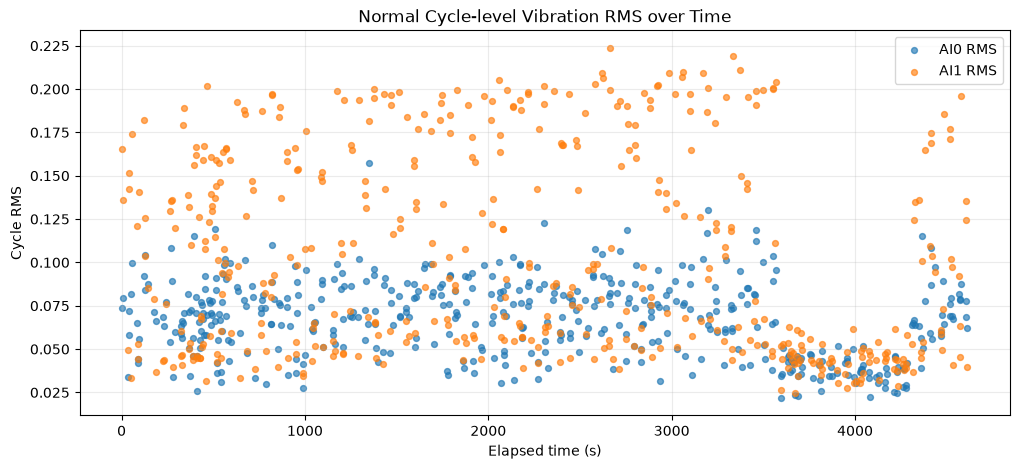

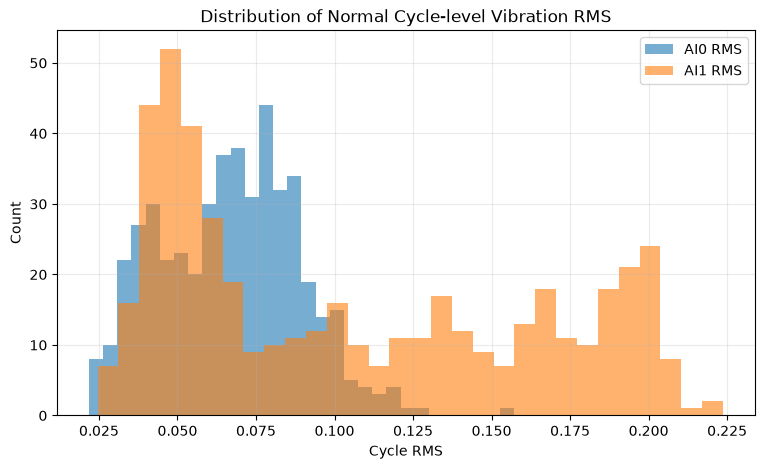

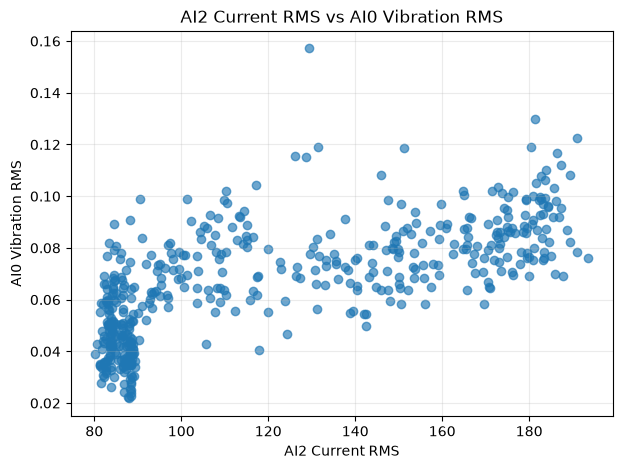

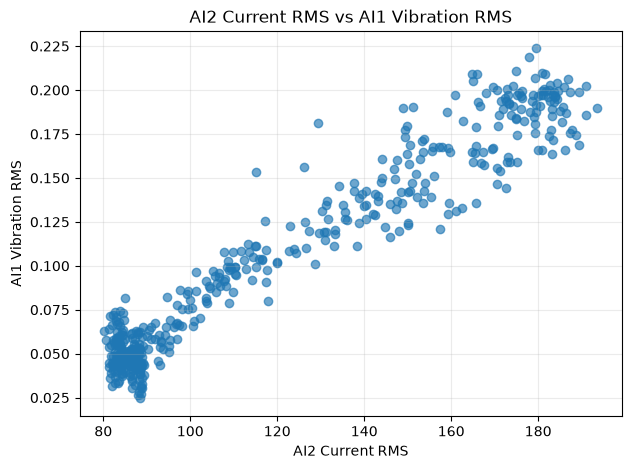

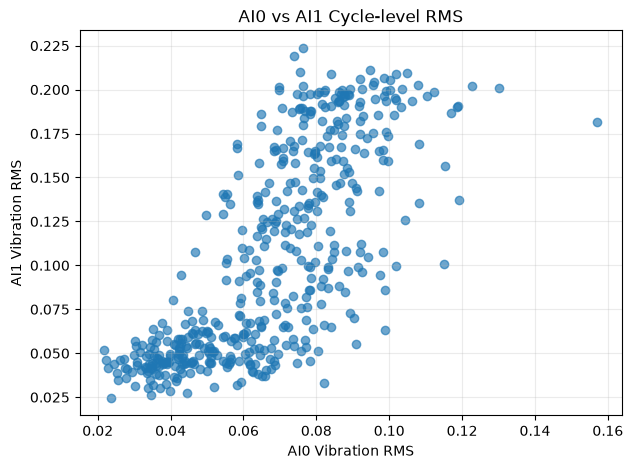

In [3]:
# AI2로 추출한 정상 Cycle 전체에서 AI0/AI1 진동 응답을 분석한다.
# Cycle별 RMS, STD, PTP의 분포와 시간에 따른 변화를 확인한다.
# AI2 Current 수준과 AI0/AI1 진동 크기의 관계도 함께 확인한다.
# 아직 Phase를 나누지 않고 전체 Cycle 단위의 Global Response만 본다.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

global_features = cycle_features.copy()

# Cycle 시작 시점을 실제 Normal elapsed time으로 연결
elapsed_map = normal.set_index("source_row")["elapsed_sec"].to_dict()
global_features["start_elapsed_sec"] = (
    global_features["start_source_row"].map(elapsed_map)
)

FEATURES = [
    "AI0_Vibration_rms",
    "AI1_Vibration_rms",
    "AI2_Current_rms",
    "AI0_Vibration_std",
    "AI1_Vibration_std",
    "AI0_Vibration_ptp",
    "AI1_Vibration_ptp",
]

# 1. Global 요약 통계
summary = global_features[FEATURES].describe(
    percentiles=[0.25, 0.5, 0.75]
).T[["mean", "std", "25%", "50%", "75%", "min", "max"]]

summary["cv"] = summary["std"] / summary["mean"].abs()

print("=== Global Cycle Response Summary ===")
display(summary.round(6))

# 2. 핵심 관계 확인
corr_pairs = {
    "AI0 RMS ↔ AI0 STD":
        global_features["AI0_Vibration_rms"].corr(
            global_features["AI0_Vibration_std"]
        ),

    "AI1 RMS ↔ AI1 STD":
        global_features["AI1_Vibration_rms"].corr(
            global_features["AI1_Vibration_std"]
        ),

    "AI2 RMS ↔ AI0 RMS":
        global_features["AI2_Current_rms"].corr(
            global_features["AI0_Vibration_rms"]
        ),

    "AI2 RMS ↔ AI1 RMS":
        global_features["AI2_Current_rms"].corr(
            global_features["AI1_Vibration_rms"]
        ),

    "AI0 RMS ↔ AI1 RMS":
        global_features["AI0_Vibration_rms"].corr(
            global_features["AI1_Vibration_rms"]
        ),
}

print("\n=== Global Correlations ===")
for name, value in corr_pairs.items():
    print(f"{name:22s}: {value:.4f}")

# 3. 시간에 따른 AI0/AI1 Cycle RMS
plt.figure(figsize=(12, 5))
plt.scatter(
    global_features["start_elapsed_sec"],
    global_features["AI0_Vibration_rms"],
    s=18,
    alpha=0.65,
    label="AI0 RMS"
)
plt.scatter(
    global_features["start_elapsed_sec"],
    global_features["AI1_Vibration_rms"],
    s=18,
    alpha=0.65,
    label="AI1 RMS"
)
plt.xlabel("Elapsed time (s)")
plt.ylabel("Cycle RMS")
plt.title("Normal Cycle-level Vibration RMS over Time")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# 4. AI0 / AI1 RMS 분포
plt.figure(figsize=(9, 5))
plt.hist(
    global_features["AI0_Vibration_rms"],
    bins=30,
    alpha=0.6,
    label="AI0 RMS"
)
plt.hist(
    global_features["AI1_Vibration_rms"],
    bins=30,
    alpha=0.6,
    label="AI1 RMS"
)
plt.xlabel("Cycle RMS")
plt.ylabel("Count")
plt.title("Distribution of Normal Cycle-level Vibration RMS")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# 5. AI2 Current RMS 대비 AI0 진동 RMS
plt.figure(figsize=(7, 5))
plt.scatter(
    global_features["AI2_Current_rms"],
    global_features["AI0_Vibration_rms"],
    alpha=0.65
)
plt.xlabel("AI2 Current RMS")
plt.ylabel("AI0 Vibration RMS")
plt.title("AI2 Current RMS vs AI0 Vibration RMS")
plt.grid(alpha=0.25)
plt.show()

# 6. AI2 Current RMS 대비 AI1 진동 RMS
plt.figure(figsize=(7, 5))
plt.scatter(
    global_features["AI2_Current_rms"],
    global_features["AI1_Vibration_rms"],
    alpha=0.65
)
plt.xlabel("AI2 Current RMS")
plt.ylabel("AI1 Vibration RMS")
plt.title("AI2 Current RMS vs AI1 Vibration RMS")
plt.grid(alpha=0.25)
plt.show()

# 7. AI0 ↔ AI1 Cycle Response
plt.figure(figsize=(7, 5))
plt.scatter(
    global_features["AI0_Vibration_rms"],
    global_features["AI1_Vibration_rms"],
    alpha=0.65
)
plt.xlabel("AI0 Vibration RMS")
plt.ylabel("AI1 Vibration RMS")
plt.title("AI0 vs AI1 Cycle-level RMS")
plt.grid(alpha=0.25)
plt.show()

=== AI2 RMS → Vibration RMS Global Regression ===
AI0: slope=0.000409, intercept=0.017214, R²=0.4889, residual std=0.015788
AI1: slope=0.001487, intercept=-0.075564, R²=0.9345, residual std=0.014849


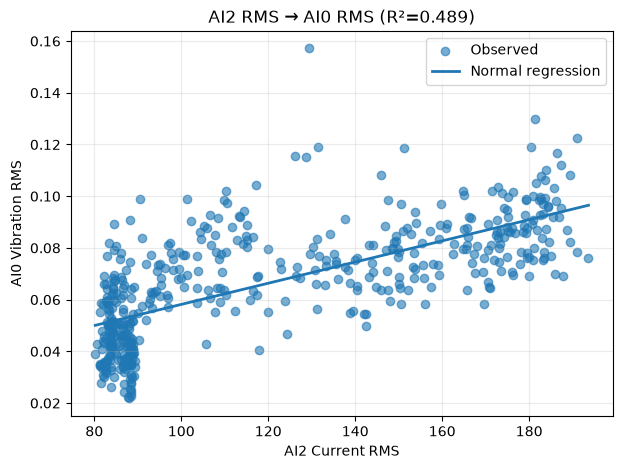

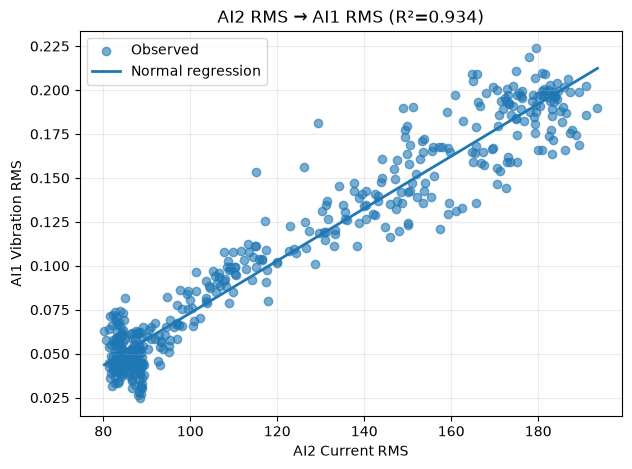

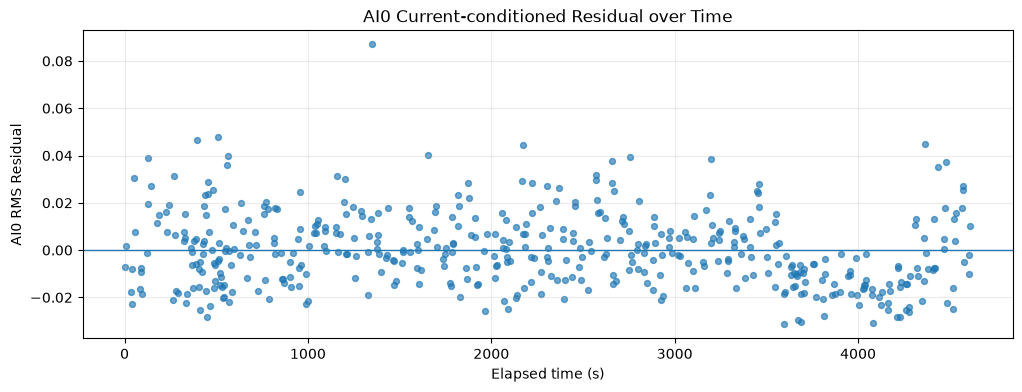

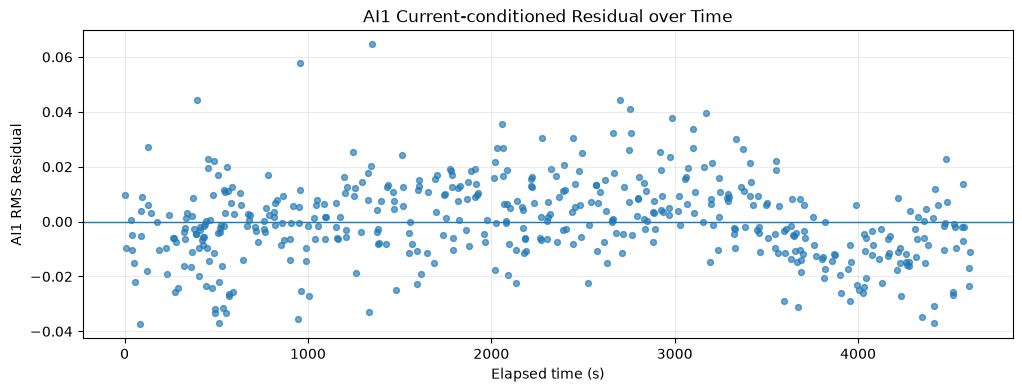

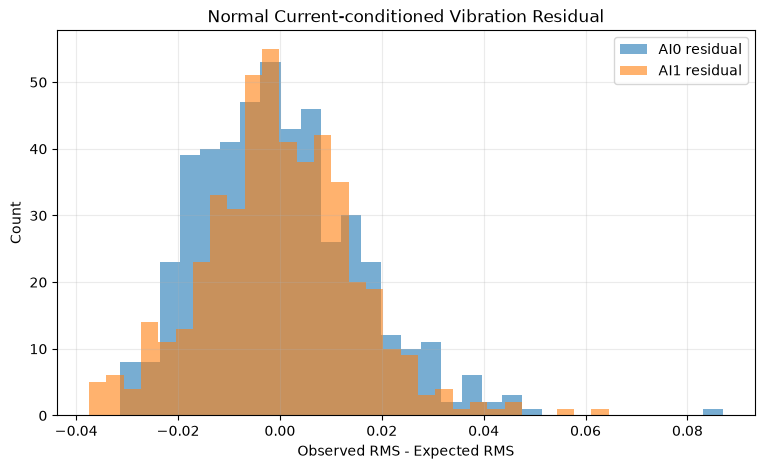

In [4]:
# Normal Cycle에서 AI2 RMS와 AI0/AI1 RMS의 Global 관계를 회귀로 정량화한다.
# AI2 수준에서 기대되는 진동 RMS를 계산하고 실제값과의 Residual을 만든다.
# Residual의 크기와 시간 변화를 통해 단순 진폭과 관계 이탈을 분리한다.
# 이 단계는 이후 Current-Vibration Coupling Feature의 기준이 된다.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

gf = global_features.copy()

x = gf[["AI2_Current_rms"]].to_numpy()

results = {}

for channel in ["AI0", "AI1"]:
    y_col = f"{channel}_Vibration_rms"
    y = gf[y_col].to_numpy()

    model = LinearRegression()
    model.fit(x, y)

    pred = model.predict(x)
    residual = y - pred

    gf[f"{channel}_pred_rms"] = pred
    gf[f"{channel}_residual"] = residual

    results[channel] = {
        "slope": model.coef_[0],
        "intercept": model.intercept_,
        "r2": r2_score(y, pred),
        "residual_mean": residual.mean(),
        "residual_std": residual.std(ddof=1)
    }

print("=== AI2 RMS → Vibration RMS Global Regression ===")
for channel, r in results.items():
    print(
        f"{channel}: "
        f"slope={r['slope']:.6f}, "
        f"intercept={r['intercept']:.6f}, "
        f"R²={r['r2']:.4f}, "
        f"residual std={r['residual_std']:.6f}"
    )

# AI2 → AI0
plt.figure(figsize=(7, 5))
plt.scatter(
    gf["AI2_Current_rms"],
    gf["AI0_Vibration_rms"],
    alpha=0.6,
    label="Observed"
)

order = np.argsort(gf["AI2_Current_rms"].to_numpy())

plt.plot(
    gf["AI2_Current_rms"].to_numpy()[order],
    gf["AI0_pred_rms"].to_numpy()[order],
    linewidth=2,
    label="Normal regression"
)

plt.xlabel("AI2 Current RMS")
plt.ylabel("AI0 Vibration RMS")
plt.title(f"AI2 RMS → AI0 RMS (R²={results['AI0']['r2']:.3f})")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# AI2 → AI1
plt.figure(figsize=(7, 5))
plt.scatter(
    gf["AI2_Current_rms"],
    gf["AI1_Vibration_rms"],
    alpha=0.6,
    label="Observed"
)

plt.plot(
    gf["AI2_Current_rms"].to_numpy()[order],
    gf["AI1_pred_rms"].to_numpy()[order],
    linewidth=2,
    label="Normal regression"
)

plt.xlabel("AI2 Current RMS")
plt.ylabel("AI1 Vibration RMS")
plt.title(f"AI2 RMS → AI1 RMS (R²={results['AI1']['r2']:.3f})")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# AI0 Residual 시간 변화
plt.figure(figsize=(12, 4))
plt.scatter(
    gf["start_elapsed_sec"],
    gf["AI0_residual"],
    s=18,
    alpha=0.65
)
plt.axhline(0, linewidth=1)
plt.xlabel("Elapsed time (s)")
plt.ylabel("AI0 RMS Residual")
plt.title("AI0 Current-conditioned Residual over Time")
plt.grid(alpha=0.25)
plt.show()

# AI1 Residual 시간 변화
plt.figure(figsize=(12, 4))
plt.scatter(
    gf["start_elapsed_sec"],
    gf["AI1_residual"],
    s=18,
    alpha=0.65
)
plt.axhline(0, linewidth=1)
plt.xlabel("Elapsed time (s)")
plt.ylabel("AI1 RMS Residual")
plt.title("AI1 Current-conditioned Residual over Time")
plt.grid(alpha=0.25)
plt.show()

# Residual 분포 비교
plt.figure(figsize=(9, 5))
plt.hist(gf["AI0_residual"], bins=30, alpha=0.6, label="AI0 residual")
plt.hist(gf["AI1_residual"], bins=30, alpha=0.6, label="AI1 residual")
plt.xlabel("Observed RMS - Expected RMS")
plt.ylabel("Count")
plt.title("Normal Current-conditioned Vibration Residual")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

=== Regime-specific Global Regression ===

[AI0]
Other    | n=408 | slope=0.000342 | intercept=0.028271 | R²=0.4225 | resid std=0.015179
Low-RMS  | n= 67 | slope=-0.000698 | intercept=0.099217 | R²=0.0091 | resid std=0.007338

[AI1]
Other    | n=408 | slope=0.001437 | intercept=-0.067448 | R²=0.9325 | resid std=0.014681
Low-RMS  | n= 67 | slope=-0.002116 | intercept=0.229523 | R²=0.0608 | resid std=0.008390


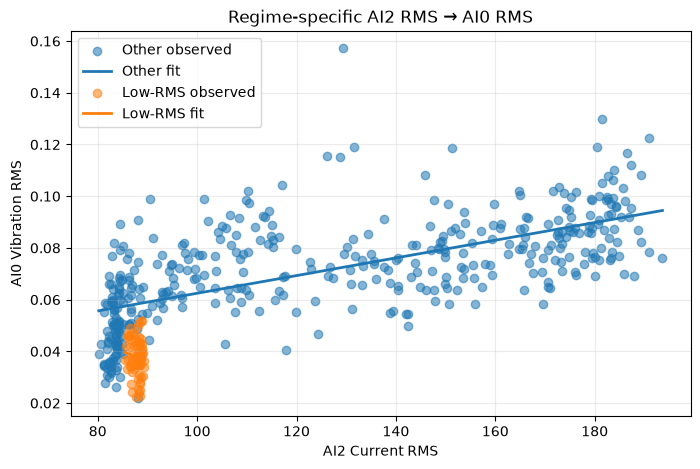

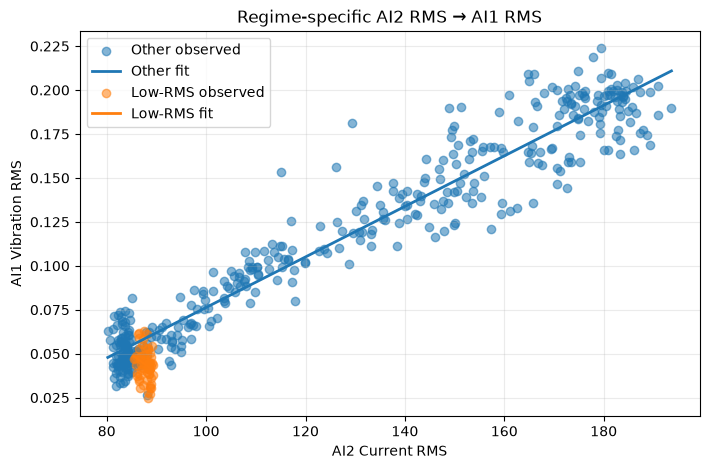


=== Global-model Residual by Regime ===


AI0_residual                     AI1_residual                    
                mean       std    median         mean       std    median
regime                                                                   
Low-RMS    -0.015218  0.007422 -0.014917    -0.011226  0.009144 -0.011988
Other       0.002499  0.015394  0.001168     0.001844  0.014801  0.001466

In [5]:
# Global Current-Vibration 관계가 Low-RMS Normal과 다른 Normal에서 같은지 비교한다.
# 기존 3600~4300초 구간은 원인 미확정의 Low-RMS candidate로만 사용한다.
# 각 regime별 AI2→AI0/AI1 회귀선, R², residual bias를 비교한다.
# 결과를 통해 단순 진폭 변화와 coupling 관계 변화를 구분한다.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

gf_regime = gf.copy()

LOW_START = 3600
LOW_END = 4300

gf_regime["regime"] = np.where(
    gf_regime["start_elapsed_sec"].between(LOW_START, LOW_END),
    "Low-RMS",
    "Other"
)

def fit_regime(df, y_col):
    x = df[["AI2_Current_rms"]].to_numpy()
    y = df[y_col].to_numpy()

    model = LinearRegression().fit(x, y)
    pred = model.predict(x)

    return {
        "n": len(df),
        "slope": model.coef_[0],
        "intercept": model.intercept_,
        "r2": r2_score(y, pred),
        "residual_mean": np.mean(y - pred),
        "residual_std": np.std(y - pred, ddof=1),
        "model": model
    }

results_regime = {}

for channel in ["AI0", "AI1"]:
    y_col = f"{channel}_Vibration_rms"

    results_regime[channel] = {
        regime: fit_regime(group, y_col)
        for regime, group in gf_regime.groupby("regime")
    }

print("=== Regime-specific Global Regression ===")

for channel in ["AI0", "AI1"]:
    print(f"\n[{channel}]")

    for regime in ["Other", "Low-RMS"]:
        r = results_regime[channel][regime]

        print(
            f"{regime:8s} | "
            f"n={r['n']:3d} | "
            f"slope={r['slope']:.6f} | "
            f"intercept={r['intercept']:.6f} | "
            f"R²={r['r2']:.4f} | "
            f"resid std={r['residual_std']:.6f}"
        )

# AI0 regime별 회귀
plt.figure(figsize=(8, 5))

for regime in ["Other", "Low-RMS"]:
    d = gf_regime[gf_regime["regime"] == regime]
    r = results_regime["AI0"][regime]

    plt.scatter(
        d["AI2_Current_rms"],
        d["AI0_Vibration_rms"],
        alpha=0.55,
        label=f"{regime} observed"
    )

    x_line = np.linspace(
        d["AI2_Current_rms"].min(),
        d["AI2_Current_rms"].max(),
        100
    ).reshape(-1, 1)

    plt.plot(
        x_line[:, 0],
        r["model"].predict(x_line),
        linewidth=2,
        label=f"{regime} fit"
    )

plt.xlabel("AI2 Current RMS")
plt.ylabel("AI0 Vibration RMS")
plt.title("Regime-specific AI2 RMS → AI0 RMS")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# AI1 regime별 회귀
plt.figure(figsize=(8, 5))

for regime in ["Other", "Low-RMS"]:
    d = gf_regime[gf_regime["regime"] == regime]
    r = results_regime["AI1"][regime]

    plt.scatter(
        d["AI2_Current_rms"],
        d["AI1_Vibration_rms"],
        alpha=0.55,
        label=f"{regime} observed"
    )

    x_line = np.linspace(
        d["AI2_Current_rms"].min(),
        d["AI2_Current_rms"].max(),
        100
    ).reshape(-1, 1)

    plt.plot(
        x_line[:, 0],
        r["model"].predict(x_line),
        linewidth=2,
        label=f"{regime} fit"
    )

plt.xlabel("AI2 Current RMS")
plt.ylabel("AI1 Vibration RMS")
plt.title("Regime-specific AI2 RMS → AI1 RMS")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# 기존 Global residual을 regime별로 비교
residual_summary = (
    gf_regime.groupby("regime")
    [["AI0_residual", "AI1_residual"]]
    .agg(["mean", "std", "median"])
)

print("\n=== Global-model Residual by Regime ===")
display(residual_summary.round(6))

In [6]:
# Low-RMS Normal이 AI2-Vibration 관계의 단순 offset인지 slope 변화인지 확인한다.
# AI2만, AI2+Regime, AI2+Regime+Interaction 세 모델을 비교한다.
# Low-RMS 내부 AI2 범위가 좁으므로 별도 회귀 slope를 직접 해석하지 않는다.
# 이 셀을 마지막 Global 진단으로 사용하고 이후 Phase 분석으로 넘어간다.

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

check = gf_regime.copy()
check["low_flag"] = (check["regime"] == "Low-RMS").astype(int)

print("=== AI2 RMS Range by Regime ===")
range_summary = (
    check.groupby("regime")["AI2_Current_rms"]
    .agg(["count", "min", "max", "mean", "std"])
)
display(range_summary.round(4))

def compare_models(df, y_col):
    y = df[y_col].to_numpy()

    X1 = df[["AI2_Current_rms"]].to_numpy()

    X2 = df[
        ["AI2_Current_rms", "low_flag"]
    ].to_numpy()

    X3 = df[
        ["AI2_Current_rms", "low_flag"]
    ].copy()

    X3["interaction"] = (
        df["AI2_Current_rms"] * df["low_flag"]
    )

    X3 = X3.to_numpy()

    models = {}

    for name, X in {
        "AI2 only": X1,
        "AI2 + Regime": X2,
        "AI2 + Regime + Interaction": X3
    }.items():

        model = LinearRegression().fit(X, y)
        pred = model.predict(X)

        models[name] = {
            "R2": r2_score(y, pred),
            "RMSE": np.sqrt(mean_squared_error(y, pred)),
            "coef": model.coef_,
            "intercept": model.intercept_
        }

    return models

all_results = {}

for channel in ["AI0", "AI1"]:
    y_col = f"{channel}_Vibration_rms"
    all_results[channel] = compare_models(check, y_col)

    print(f"\n=== {channel} Model Comparison ===")

    for name, r in all_results[channel].items():
        print(
            f"{name:28s} | "
            f"R²={r['R2']:.4f} | "
            f"RMSE={r['RMSE']:.6f}"
        )

    r2 = all_results[channel]["AI2 + Regime"]
    r3 = all_results[channel]["AI2 + Regime + Interaction"]

    print(
        f"\n{channel} Regime offset coefficient : "
        f"{r2['coef'][1]:.6f}"
    )

    print(
        f"{channel} Interaction coefficient    : "
        f"{r3['coef'][2]:.6f}"
    )

# Global model residual의 regime 차이
print("\n=== Global Residual Difference ===")

for channel in ["AI0", "AI1"]:
    col = f"{channel}_residual"

    low = check.loc[check["regime"] == "Low-RMS", col]
    other = check.loc[check["regime"] == "Other", col]

    pooled_std = np.sqrt(
        (
            (len(low)-1) * low.var(ddof=1)
            + (len(other)-1) * other.var(ddof=1)
        )
        / (len(low)+len(other)-2)
    )

    effect_size = (
        low.mean() - other.mean()
    ) / pooled_std

    print(
        f"{channel}: "
        f"Low mean={low.mean():.6f}, "
        f"Other mean={other.mean():.6f}, "
        f"Cohen d={effect_size:.3f}"
    )

=== AI2 RMS Range by Regime ===


,count,min,max,mean,std
regime,,,,,
Low-RMS,67,85.5150,89.4074,87.7843,1.0089
Other,408,80.2207,193.6256,126.7171,37.9668



=== AI0 Model Comparison ===
AI2 only                     | R²=0.4889 | RMSE=0.015772
AI2 + Regime                 | R²=0.5786 | RMSE=0.014320
AI2 + Regime + Interaction   | R²=0.5789 | RMSE=0.014315

AI0 Regime offset coefficient : -0.020351
AI0 Interaction coefficient    : -0.001040

=== AI1 Model Comparison ===
AI2 only                     | R²=0.9345 | RMSE=0.014833
AI2 + Regime                 | R²=0.9415 | RMSE=0.014009
AI2 + Regime + Interaction   | R²=0.9421 | RMSE=0.013945

AI1 Regime offset coefficient : -0.015013
AI1 Interaction coefficient    : -0.003554

=== Global Residual Difference ===
AI0: Low mean=-0.015218, Other mean=0.002499, Cohen d=-1.218
AI1: Low mean=-0.011226, Other mean=0.001844, Cohen d=-0.924


=== Phase Extraction ===
Cycles          : 475
Phase rows      : 1425

Samples per phase:
       min  median  max
phase                  
A        6     6.0    6
B        5     6.0    6
C        5     5.0    5

=== AI0_Vibration Phase Summary ===


,rms_median,rms_q25,rms_q75,ratio_median,ratio_q25,ratio_q75
phase,,,,,,
A,0.064062,0.043415,0.083632,1.007625,0.855465,1.147175
B,0.060953,0.046304,0.080786,0.986474,0.852472,1.092824
C,0.059951,0.042177,0.081965,0.980438,0.777815,1.138925


Relative RMS max/min median ratio: 1.028

=== AI1_Vibration Phase Summary ===


,rms_median,rms_q25,rms_q75,ratio_median,ratio_q25,ratio_q75
phase,,,,,,
A,0.089642,0.050242,0.159267,1.003969,0.928417,1.065596
B,0.087302,0.051004,0.159562,0.993018,0.912069,1.068931
C,0.088300,0.049513,0.155030,0.986922,0.882072,1.076862


Relative RMS max/min median ratio: 1.017


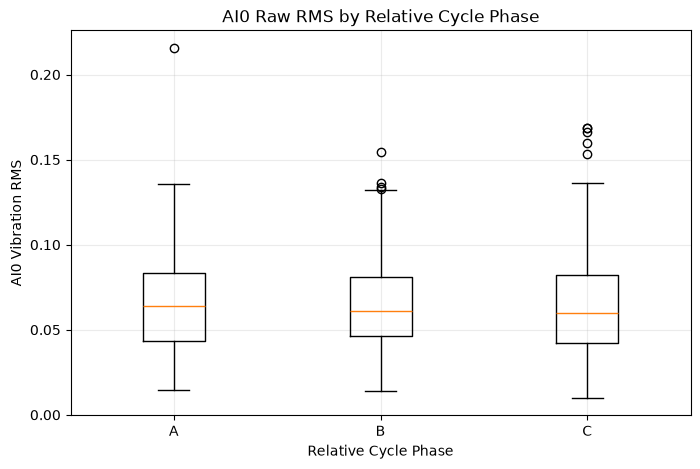

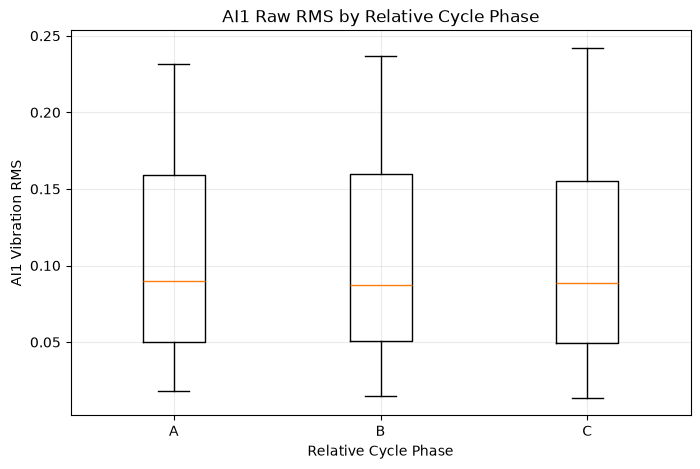

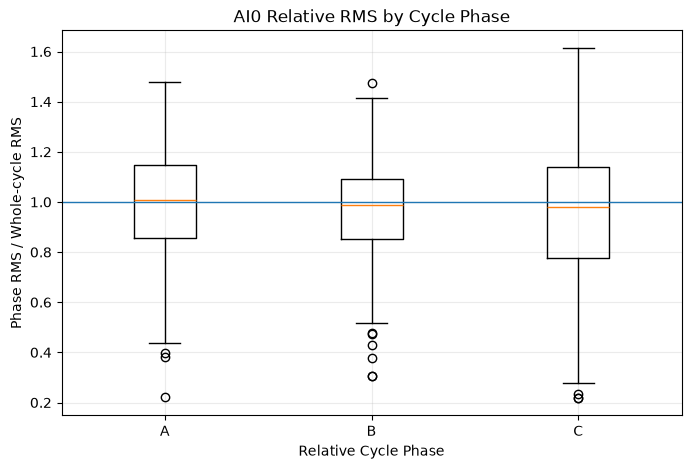

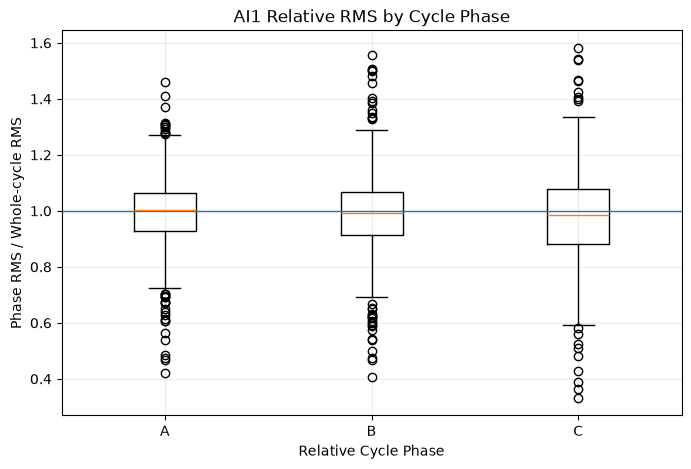

In [7]:
# AI2 Peak-to-Peak Cycle을 상대시간 기준 A/B/C 3개 Phase로 나눈다.
# 각 Phase에서 AI0/AI1 진동의 RMS, STD, PTP, 평균절대값을 계산한다.
# 전체 Cycle RMS로 나눈 relative RMS도 만들어 amplitude와 phase 구조를 분리한다.
# Cycle 마지막 peak는 다음 Cycle과 중복되므로 Phase 계산에서는 제외한다.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PHASE_NAMES = ["A", "B", "C"]
CHANNELS_PHASE = ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]

phase_records = []

for _, bound in cycle_bounds.iterrows():
    segment_id = bound["segment_id"]
    cycle_id = bound["cycle_id"]

    cycle = normal.loc[
        int(bound["start_idx"]):int(bound["end_idx"])
    ].copy()

    # 다음 Cycle의 첫 peak와 중복되는 마지막 endpoint 제거
    if len(cycle) < 4:
        continue

    cycle_core = cycle.iloc[:-1].copy()

    # Cycle 전체 기준 통계
    cycle_rms = {}
    for channel in CHANNELS_PHASE:
        x = cycle_core[channel].to_numpy(float)
        cycle_rms[channel] = np.sqrt(np.mean(x**2))

    # 실제 샘플을 보간하지 않고 3개 상대구간으로 분리
    phase_indices = np.array_split(
        np.arange(len(cycle_core)),
        3
    )

    for phase_name, idx in zip(PHASE_NAMES, phase_indices):
        phase = cycle_core.iloc[idx]

        record = {
            "segment_id": segment_id,
            "cycle_id": cycle_id,
            "phase": phase_name,
            "n_samples": len(phase),
            "cycle_start_elapsed_sec": float(
                cycle_core["elapsed_sec"].iloc[0]
            )
        }

        for channel in CHANNELS_PHASE:
            x = phase[channel].to_numpy(float)

            rms = np.sqrt(np.mean(x**2))

            record[f"{channel}_mean"] = np.mean(x)
            record[f"{channel}_std"] = (
                np.std(x, ddof=1) if len(x) > 1 else np.nan
            )
            record[f"{channel}_rms"] = rms
            record[f"{channel}_ptp"] = np.ptp(x)
            record[f"{channel}_mean_abs"] = np.mean(np.abs(x))
            record[f"{channel}_rms_ratio"] = (
                rms / cycle_rms[channel]
                if cycle_rms[channel] > 0
                else np.nan
            )

        phase_records.append(record)

phase_features = pd.DataFrame(phase_records)

print("=== Phase Extraction ===")
print(f"Cycles          : {phase_features[['segment_id','cycle_id']].drop_duplicates().shape[0]}")
print(f"Phase rows      : {len(phase_features)}")
print("\nSamples per phase:")
print(
    phase_features.groupby("phase")["n_samples"]
    .agg(["min", "median", "max"])
)

def q25(x):
    return x.quantile(0.25)

def q75(x):
    return x.quantile(0.75)

# Phase별 Raw RMS + Relative RMS 요약
for channel in ["AI0_Vibration", "AI1_Vibration"]:
    summary = (
        phase_features.groupby("phase")
        .agg(
            rms_median=(f"{channel}_rms", "median"),
            rms_q25=(f"{channel}_rms", q25),
            rms_q75=(f"{channel}_rms", q75),
            ratio_median=(f"{channel}_rms_ratio", "median"),
            ratio_q25=(f"{channel}_rms_ratio", q25),
            ratio_q75=(f"{channel}_rms_ratio", q75),
        )
        .reindex(PHASE_NAMES)
    )

    print(f"\n=== {channel} Phase Summary ===")
    display(summary.round(6))

    med = summary["ratio_median"]
    print(
        f"Relative RMS max/min median ratio: "
        f"{med.max() / med.min():.3f}"
    )

# ---------------------------
# AI0 Raw Phase RMS
# ---------------------------
plt.figure(figsize=(8, 5))
plt.boxplot(
    [
        phase_features.loc[
            phase_features["phase"] == p,
            "AI0_Vibration_rms"
        ].dropna()
        for p in PHASE_NAMES
    ],
    tick_labels=PHASE_NAMES
)
plt.xlabel("Relative Cycle Phase")
plt.ylabel("AI0 Vibration RMS")
plt.title("AI0 Raw RMS by Relative Cycle Phase")
plt.grid(alpha=0.25)
plt.show()

# ---------------------------
# AI1 Raw Phase RMS
# ---------------------------
plt.figure(figsize=(8, 5))
plt.boxplot(
    [
        phase_features.loc[
            phase_features["phase"] == p,
            "AI1_Vibration_rms"
        ].dropna()
        for p in PHASE_NAMES
    ],
    tick_labels=PHASE_NAMES
)
plt.xlabel("Relative Cycle Phase")
plt.ylabel("AI1 Vibration RMS")
plt.title("AI1 Raw RMS by Relative Cycle Phase")
plt.grid(alpha=0.25)
plt.show()

# ---------------------------
# AI0 Relative Phase RMS
# ---------------------------
plt.figure(figsize=(8, 5))
plt.boxplot(
    [
        phase_features.loc[
            phase_features["phase"] == p,
            "AI0_Vibration_rms_ratio"
        ].dropna()
        for p in PHASE_NAMES
    ],
    tick_labels=PHASE_NAMES
)
plt.axhline(1.0, linewidth=1)
plt.xlabel("Relative Cycle Phase")
plt.ylabel("Phase RMS / Whole-cycle RMS")
plt.title("AI0 Relative RMS by Cycle Phase")
plt.grid(alpha=0.25)
plt.show()

# ---------------------------
# AI1 Relative Phase RMS
# ---------------------------
plt.figure(figsize=(8, 5))
plt.boxplot(
    [
        phase_features.loc[
            phase_features["phase"] == p,
            "AI1_Vibration_rms_ratio"
        ].dropna()
        for p in PHASE_NAMES
    ],
    tick_labels=PHASE_NAMES
)
plt.axhline(1.0, linewidth=1)
plt.xlabel("Relative Cycle Phase")
plt.ylabel("Phase RMS / Whole-cycle RMS")
plt.title("AI1 Relative RMS by Cycle Phase")
plt.grid(alpha=0.25)
plt.show()

In [8]:
# A/B/C Phase의 RMS 차이가 실제로 반복되는 구조인지 정량적으로 검증한다.
# AI0/AI1뿐 아니라 AI2도 같이 비교해 균등 3분할 자체의 의미를 확인한다.
# p-value보다 Kendall's W와 최대 Phase 비율을 중심으로 효과 크기를 판단한다.
# 이 결과로 3분할 Phase feature 유지 여부를 결정한다.

import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare

PHASES = ["A", "B", "C"]

def evaluate_phase_structure(df, channel):
    value_col = f"{channel}_rms_ratio"

    pivot = (
        df.pivot_table(
            index=["segment_id", "cycle_id"],
            columns="phase",
            values=value_col
        )
        .reindex(columns=PHASES)
        .dropna()
    )

    stat, p = friedmanchisquare(
        pivot["A"],
        pivot["B"],
        pivot["C"]
    )

    n = len(pivot)
    k = len(PHASES)

    # Friedman statistic 기반 Kendall's W
    kendall_w = stat / (n * (k - 1))

    # Cycle마다 가장 RMS가 큰 Phase
    max_phase = pivot.idxmax(axis=1)

    max_share = (
        max_phase.value_counts(normalize=True)
        .reindex(PHASES, fill_value=0)
    )

    # Cycle 내부 Phase 차이
    phase_range = pivot.max(axis=1) - pivot.min(axis=1)

    return {
        "n": n,
        "friedman_stat": stat,
        "p_value": p,
        "kendall_w": kendall_w,
        "median_phase_range": phase_range.median(),
        "q75_phase_range": phase_range.quantile(0.75),
        "max_phase_share": max_share,
        "phase_median": pivot.median()
    }

results_phase = {}

for channel in [
    "AI0_Vibration",
    "AI1_Vibration",
    "AI2_Current"
]:
    r = evaluate_phase_structure(
        phase_features,
        channel
    )

    results_phase[channel] = r

    print(f"\n=== {channel} ===")
    print(f"Cycles              : {r['n']}")
    print(f"Friedman statistic  : {r['friedman_stat']:.4f}")
    print(f"p-value             : {r['p_value']:.6g}")
    print(f"Kendall W           : {r['kendall_w']:.4f}")
    print(
        f"Median phase range  : "
        f"{r['median_phase_range']:.4f}"
    )
    print(
        f"75% phase range     : "
        f"{r['q75_phase_range']:.4f}"
    )

    print("\nPhase median ratio")
    print(r["phase_median"].round(4))

    print("\nMax RMS phase share")
    print(
        (r["max_phase_share"] * 100)
        .round(1)
        .astype(str) + "%"
    )


=== AI0_Vibration ===
Cycles              : 475
Friedman statistic  : 1.5326
p-value             : 0.464722
Kendall W           : 0.0016
Median phase range  : 0.4312
75% phase range     : 0.6412

Phase median ratio
phase
A    1.0076
B    0.9865
C    0.9804
dtype: float64

Max RMS phase share
A    38.3%
B    28.6%
C    33.1%
Name: proportion, dtype: str

=== AI1_Vibration ===
Cycles              : 475
Friedman statistic  : 1.6968
p-value             : 0.42809
Kendall W           : 0.0018
Median phase range  : 0.2335
75% phase range     : 0.4044

Phase median ratio
phase
A    1.0040
B    0.9930
C    0.9869
dtype: float64

Max RMS phase share
A    33.9%
B    33.1%
C    33.1%
Name: proportion, dtype: str

=== AI2_Current ===
Cycles              : 475
Friedman statistic  : 909.8568
p-value             : 2.6736e-198
Kendall W           : 0.9577
Median phase range  : 0.4112
75% phase range     : 0.4478

Phase median ratio
phase
A    1.0320
B    1.1361
C    0.7428
dtype: float64

Max RMS phas

## 3페이즈 균등 분리는 폐기

=== AI2 Normal Cycle Template ===
Cycles used      : 475
Phase grid points: 17

=== AI2 Landmarks ===


,landmark,relative_phase,phase_percent
0,Maximum,0.0625,6.250
1,Minimum,0.5625,56.250
2,Max Rise,0.9062,90.625
3,Max Fall,0.3438,34.375


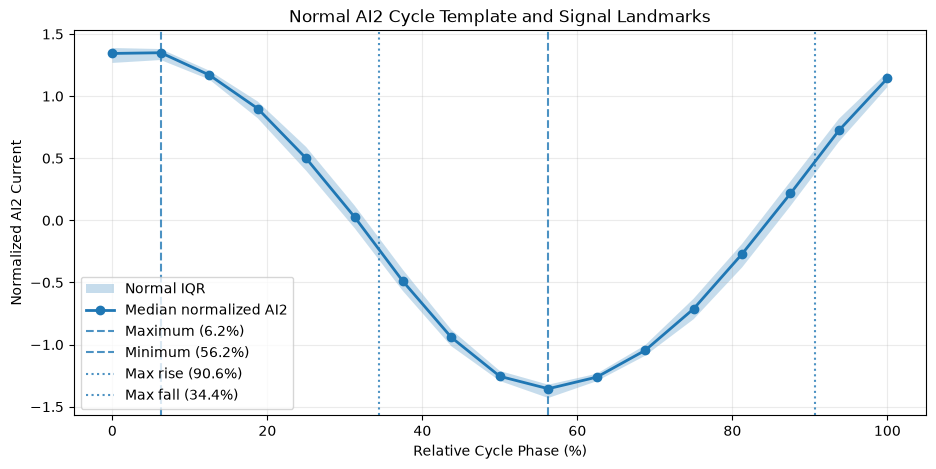

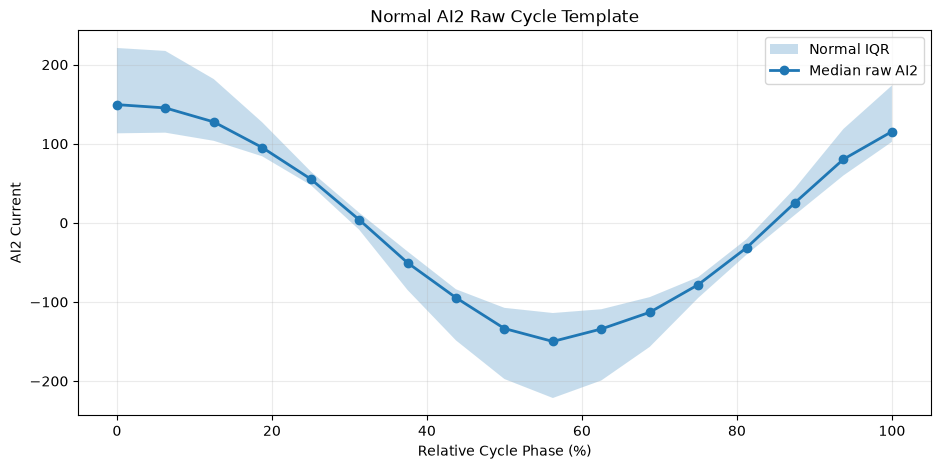

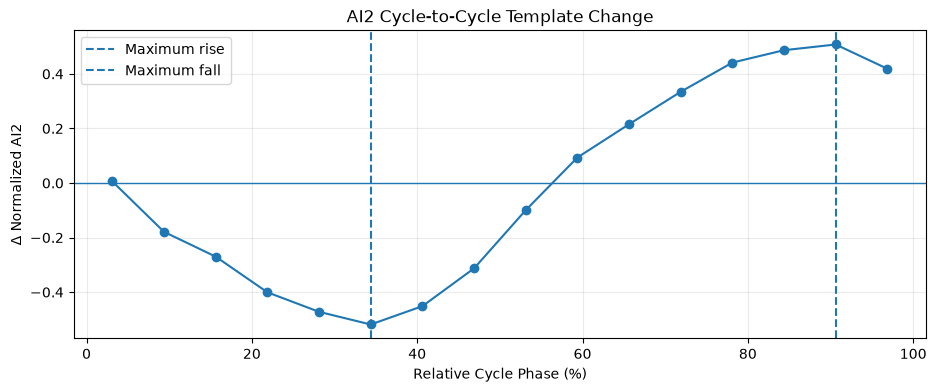

In [9]:
# 정상 AI2 Cycle을 상대위상 기준으로 정렬해 대표 Cycle Template을 만든다.
# Cycle마다 amplitude 차이를 제거한 뒤 반복되는 AI2 shape 자체를 비교한다.
# Template에서 최대/최소 및 가장 큰 상승·하강 변화구간을 Landmark로 추출한다.
# 이후 AI0/AI1 진동이 이 Landmark 주변에서 반응하는지 검증하는 기준으로 사용한다.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

N_PHASE_POINTS = 17
phase_grid = np.linspace(0, 1, N_PHASE_POINTS)

ai2_cycles_norm = []
ai2_cycles_raw = []
cycle_keys = []

for _, bound in cycle_bounds.iterrows():
    cycle = normal.loc[
        int(bound["start_idx"]):int(bound["end_idx"])
    ].copy()

    # 다음 Cycle 첫 peak와 중복되는 마지막 endpoint 제거
    if len(cycle) < 4:
        continue

    cycle_core = cycle.iloc[:-1].copy()
    x = cycle_core["AI2_Current"].to_numpy(float)

    if len(x) < 3 or np.std(x, ddof=1) == 0:
        continue

    original_phase = np.linspace(0, 1, len(x))

    # 공통 상대위상 grid로만 보간
    x_raw_interp = np.interp(
        phase_grid,
        original_phase,
        x
    )

    # Cycle별 amplitude/offset 제거 후 shape 비교
    x_norm = (x - np.mean(x)) / np.std(x, ddof=1)

    x_norm_interp = np.interp(
        phase_grid,
        original_phase,
        x_norm
    )

    ai2_cycles_raw.append(x_raw_interp)
    ai2_cycles_norm.append(x_norm_interp)

    cycle_keys.append(
        (
            bound["segment_id"],
            bound["cycle_id"]
        )
    )

ai2_cycles_raw = np.asarray(ai2_cycles_raw)
ai2_cycles_norm = np.asarray(ai2_cycles_norm)

# 475개 Normal Cycle의 대표 Template
template_median = np.median(ai2_cycles_norm, axis=0)
template_q25 = np.quantile(ai2_cycles_norm, 0.25, axis=0)
template_q75 = np.quantile(ai2_cycles_norm, 0.75, axis=0)

raw_template_median = np.median(ai2_cycles_raw, axis=0)
raw_template_q25 = np.quantile(ai2_cycles_raw, 0.25, axis=0)
raw_template_q75 = np.quantile(ai2_cycles_raw, 0.75, axis=0)

# Template 주요 Landmark
max_idx = int(np.argmax(template_median))
min_idx = int(np.argmin(template_median))

diff_template = np.diff(template_median)
rise_idx = int(np.argmax(diff_template))
fall_idx = int(np.argmin(diff_template))

# Rise/Fall은 두 점 사이 변화이므로 midpoint 사용
max_phase = phase_grid[max_idx]
min_phase = phase_grid[min_idx]
rise_phase = (phase_grid[rise_idx] + phase_grid[rise_idx + 1]) / 2
fall_phase = (phase_grid[fall_idx] + phase_grid[fall_idx + 1]) / 2

landmarks = pd.DataFrame({
    "landmark": [
        "Maximum",
        "Minimum",
        "Max Rise",
        "Max Fall"
    ],
    "relative_phase": [
        max_phase,
        min_phase,
        rise_phase,
        fall_phase
    ],
    "phase_percent": [
        max_phase * 100,
        min_phase * 100,
        rise_phase * 100,
        fall_phase * 100
    ]
})

print("=== AI2 Normal Cycle Template ===")
print(f"Cycles used      : {len(ai2_cycles_norm)}")
print(f"Phase grid points: {N_PHASE_POINTS}")

print("\n=== AI2 Landmarks ===")
display(landmarks.round(4))

# -------------------------------------------------
# 1. Normalized AI2 Cycle Template
# -------------------------------------------------
plt.figure(figsize=(11, 5))

plt.fill_between(
    phase_grid * 100,
    template_q25,
    template_q75,
    alpha=0.25,
    label="Normal IQR"
)

plt.plot(
    phase_grid * 100,
    template_median,
    marker="o",
    linewidth=2,
    label="Median normalized AI2"
)

plt.axvline(
    max_phase * 100,
    linestyle="--",
    alpha=0.8,
    label=f"Maximum ({max_phase*100:.1f}%)"
)

plt.axvline(
    min_phase * 100,
    linestyle="--",
    alpha=0.8,
    label=f"Minimum ({min_phase*100:.1f}%)"
)

plt.axvline(
    rise_phase * 100,
    linestyle=":",
    alpha=0.8,
    label=f"Max rise ({rise_phase*100:.1f}%)"
)

plt.axvline(
    fall_phase * 100,
    linestyle=":",
    alpha=0.8,
    label=f"Max fall ({fall_phase*100:.1f}%)"
)

plt.xlabel("Relative Cycle Phase (%)")
plt.ylabel("Normalized AI2 Current")
plt.title("Normal AI2 Cycle Template and Signal Landmarks")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# -------------------------------------------------
# 2. Raw AI2 Median Cycle
# -------------------------------------------------
plt.figure(figsize=(11, 5))

plt.fill_between(
    phase_grid * 100,
    raw_template_q25,
    raw_template_q75,
    alpha=0.25,
    label="Normal IQR"
)

plt.plot(
    phase_grid * 100,
    raw_template_median,
    marker="o",
    linewidth=2,
    label="Median raw AI2"
)

plt.xlabel("Relative Cycle Phase (%)")
plt.ylabel("AI2 Current")
plt.title("Normal AI2 Raw Cycle Template")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# -------------------------------------------------
# 3. AI2 Template 변화량
# -------------------------------------------------
diff_phase = (
    (phase_grid[:-1] + phase_grid[1:]) / 2
)

plt.figure(figsize=(11, 4))

plt.plot(
    diff_phase * 100,
    diff_template,
    marker="o"
)

plt.axhline(0, linewidth=1)

plt.axvline(
    rise_phase * 100,
    linestyle="--",
    label="Maximum rise"
)

plt.axvline(
    fall_phase * 100,
    linestyle="--",
    label="Maximum fall"
)

plt.xlabel("Relative Cycle Phase (%)")
plt.ylabel("Δ Normalized AI2")
plt.title("AI2 Cycle-to-Cycle Template Change")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

=== Landmark Local Response ===
Cycles : 475
Rows   : 1425

=== AI0_Vibration Landmark RMS Ratio ===


,median,mean,std
landmark,,,
Max Fall,0.9455,0.9243,0.3187
Minimum,0.9417,0.9375,0.2934
Max Rise,0.9463,0.9417,0.3542


Friedman p-value : 0.960789
Kendall W        : 0.0001

Max local RMS landmark share
Max Fall    34.9%
Minimum     28.4%
Max Rise    36.6%
Name: proportion, dtype: str

=== AI1_Vibration Landmark RMS Ratio ===


,median,mean,std
landmark,,,
Max Fall,0.9698,0.9697,0.2574
Minimum,0.9591,0.9501,0.2579
Max Rise,0.9873,0.9774,0.2635


Friedman p-value : 0.104681
Kendall W        : 0.0048

Max local RMS landmark share
Max Fall    37.3%
Minimum     26.7%
Max Rise    36.0%
Name: proportion, dtype: str


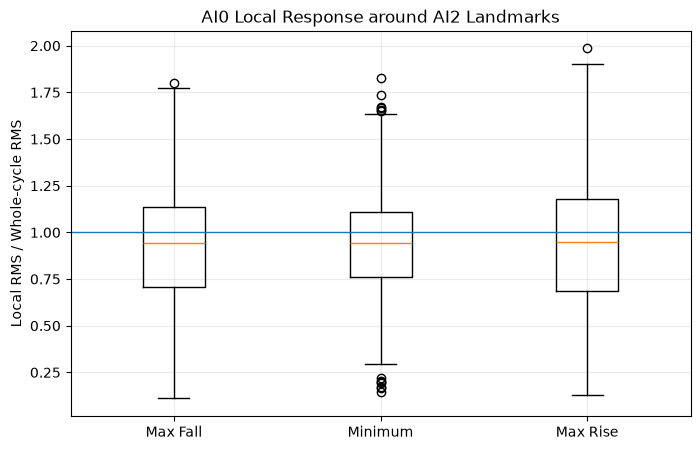

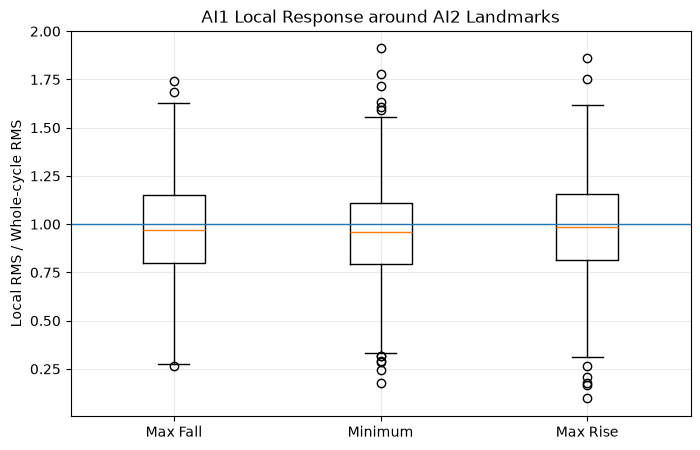


AI0_Vibration median Local PTP
landmark
Max Fall    0.104643
Minimum     0.107958
Max Rise    0.104133
Name: AI0_Vibration_ptp, dtype: float64

AI1_Vibration median Local PTP
landmark
Max Fall    0.147582
Minimum     0.145981
Max Rise    0.146821
Name: AI1_Vibration_ptp, dtype: float64


In [27]:
# AI2 template의 Max Fall, Minimum, Max Rise 주변에서 AI0/AI1 국소 진동을 측정한다.
# 보간된 진동값은 사용하지 않고 각 Cycle의 실제 저장 샘플에서 ±1 sample window를 사용한다.
# Local RMS를 Whole-cycle RMS로 나눠 특정 AI2 transition 주변에 진동이 집중되는지 확인한다.
# Friedman 검정과 최대-response 비율로 landmark별 반복성을 함께 평가한다.
# 10번째 셀임

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare

LANDMARKS = {
    "Max Fall": fall_phase,
    "Minimum": min_phase,
    "Max Rise": rise_phase
}

LOCAL_RADIUS = 1
landmark_records = []

for _, bound in cycle_bounds.iterrows():
    cycle = normal.loc[
        int(bound["start_idx"]):int(bound["end_idx"])
    ].copy()

    if len(cycle) < 5:
        continue

    # 다음 Cycle peak와 중복되는 마지막 endpoint 제외
    cycle_core = cycle.iloc[:-1].copy()
    n = len(cycle_core)
    sample_phase = np.linspace(0, 1, n)

    whole_rms = {}
    for channel in ["AI0_Vibration", "AI1_Vibration"]:
        x = cycle_core[channel].to_numpy(float)
        whole_rms[channel] = np.sqrt(np.mean(x**2))

    for landmark_name, target_phase in LANDMARKS.items():
        center = int(np.argmin(np.abs(sample_phase - target_phase)))

        start = max(0, center - LOCAL_RADIUS)
        stop = min(n, center + LOCAL_RADIUS + 1)

        local = cycle_core.iloc[start:stop]

        record = {
            "segment_id": bound["segment_id"],
            "cycle_id": bound["cycle_id"],
            "landmark": landmark_name,
            "target_phase": target_phase,
            "actual_phase": sample_phase[center],
            "center_index": center,
            "n_local": len(local)
        }

        for channel in ["AI0_Vibration", "AI1_Vibration"]:
            x = local[channel].to_numpy(float)

            rms = np.sqrt(np.mean(x**2))

            record[f"{channel}_rms"] = rms
            record[f"{channel}_ptp"] = np.ptp(x)
            record[f"{channel}_rms_ratio"] = (
                rms / whole_rms[channel]
                if whole_rms[channel] > 0 else np.nan
            )

        landmark_records.append(record)

landmark_features = pd.DataFrame(landmark_records)

print("=== Landmark Local Response ===")
print(
    f"Cycles : "
    f"{landmark_features[['segment_id','cycle_id']].drop_duplicates().shape[0]}"
)
print(f"Rows   : {len(landmark_features)}")

# --------------------------------------------------
# Landmark별 요약 + 반복성 검정
# --------------------------------------------------
for channel in ["AI0_Vibration", "AI1_Vibration"]:
    value_col = f"{channel}_rms_ratio"

    summary = (
        landmark_features.groupby("landmark")[value_col]
        .agg(["median", "mean", "std"])
        .reindex(LANDMARKS.keys())
    )

    print(f"\n=== {channel} Landmark RMS Ratio ===")
    display(summary.round(4))

    pivot = (
        landmark_features.pivot_table(
            index=["segment_id", "cycle_id"],
            columns="landmark",
            values=value_col
        )
        .reindex(columns=LANDMARKS.keys())
        .dropna()
    )

    stat, p = friedmanchisquare(
        pivot["Max Fall"],
        pivot["Minimum"],
        pivot["Max Rise"]
    )

    n = len(pivot)
    k = 3
    kendall_w = stat / (n * (k - 1))

    max_share = (
        pivot.idxmax(axis=1)
        .value_counts(normalize=True)
        .reindex(LANDMARKS.keys(), fill_value=0)
    )

    print(f"Friedman p-value : {p:.6g}")
    print(f"Kendall W        : {kendall_w:.4f}")
    print("\nMax local RMS landmark share")
    print((max_share * 100).round(1).astype(str) + "%")

# --------------------------------------------------
# AI0 Local RMS Ratio
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.boxplot(
    [
        landmark_features.loc[
            landmark_features["landmark"] == lm,
            "AI0_Vibration_rms_ratio"
        ].dropna()
        for lm in LANDMARKS
    ],
    tick_labels=list(LANDMARKS.keys())
)
plt.axhline(1.0, linewidth=1)
plt.ylabel("Local RMS / Whole-cycle RMS")
plt.title("AI0 Local Response around AI2 Landmarks")
plt.grid(alpha=0.25)
plt.show()

# --------------------------------------------------
# AI1 Local RMS Ratio
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.boxplot(
    [
        landmark_features.loc[
            landmark_features["landmark"] == lm,
            "AI1_Vibration_rms_ratio"
        ].dropna()
        for lm in LANDMARKS
    ],
    tick_labels=list(LANDMARKS.keys())
)
plt.axhline(1.0, linewidth=1)
plt.ylabel("Local RMS / Whole-cycle RMS")
plt.title("AI1 Local Response around AI2 Landmarks")
plt.grid(alpha=0.25)
plt.show()

# --------------------------------------------------
# Local PTP도 보조 확인
# --------------------------------------------------
for channel in ["AI0_Vibration", "AI1_Vibration"]:
    ptp_summary = (
        landmark_features.groupby("landmark")[f"{channel}_ptp"]
        .median()
        .reindex(LANDMARKS.keys())
    )

    print(f"\n{channel} median Local PTP")
    print(ptp_summary.round(6))

=== Current-conditioned Vibration Coupling ===
Overall residual correlation : 0.3678
Other    residual correlation : 0.2783
Low-RMS  residual correlation : 0.3883

=== Incremental Channel Information ===
AI0 ~ AI2          : R²=0.4889
AI0 ~ AI2 + AI1    : R²=0.5580 (Δ=+0.0692)

AI1 ~ AI2          : R²=0.9345
AI1 ~ AI2 + AI0    : R²=0.9433 (Δ=+0.0089)

=== AI0 / AI1 Channel Balance ===


,count,mean,std,median
regime,,,,
Low-RMS,67,-0.1424,0.2389,-0.1467
Other,408,-0.3741,0.4068,-0.4514


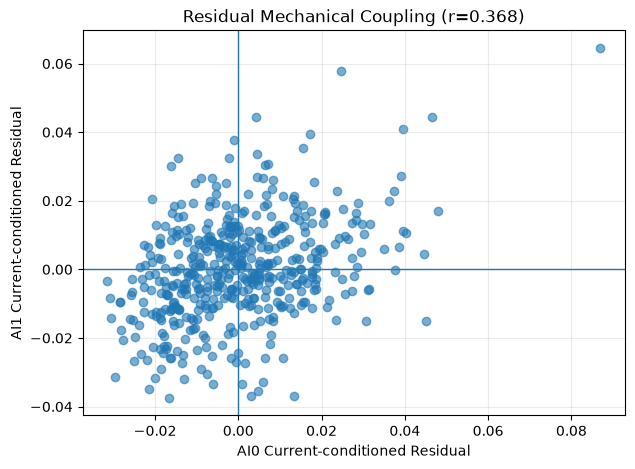

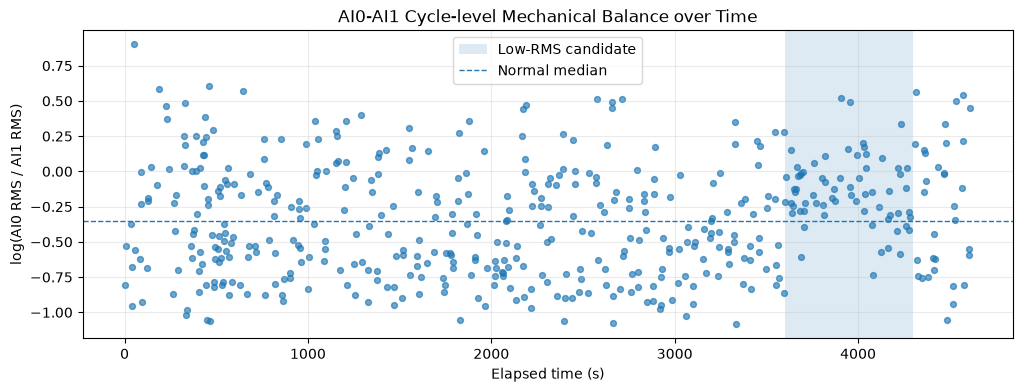

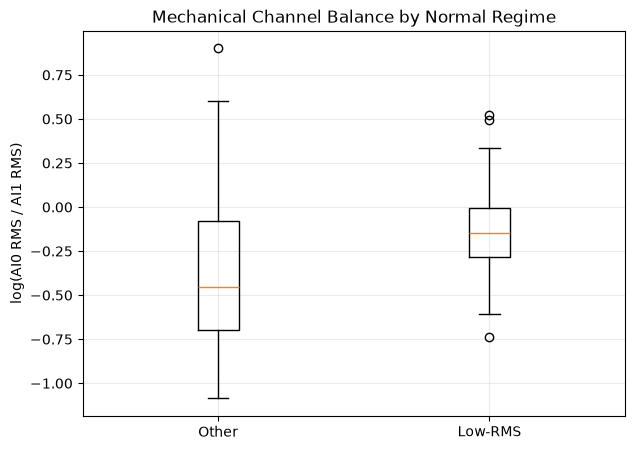

In [11]:
# AI2 Current의 영향을 제거한 뒤 AI0/AI1 진동 사이에 공통 Mechanical Response가 남는지 확인한다.
# AI0/AI1 residual correlation을 계산해 Current와 독립적인 채널 coupling을 분석한다.
# 두 진동 RMS의 log-ratio를 Channel Balance feature로 만들어 시간과 regime 변화를 확인한다.
# Phase 분석 대신 Cycle-level coupling 구조를 Feature Engineering 후보로 평가한다.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

coupling = gf_regime.copy()

# --------------------------------------------------
# 1. AI2 영향을 제거한 AI0 / AI1 residual 관계
# --------------------------------------------------
residual_corr = coupling["AI0_residual"].corr(
    coupling["AI1_residual"]
)

print("=== Current-conditioned Vibration Coupling ===")
print(f"Overall residual correlation : {residual_corr:.4f}")

for regime in ["Other", "Low-RMS"]:
    d = coupling[coupling["regime"] == regime]

    corr = d["AI0_residual"].corr(
        d["AI1_residual"]
    )

    print(
        f"{regime:8s} residual correlation : "
        f"{corr:.4f}"
    )

# --------------------------------------------------
# 2. AI1이 AI0 설명력을 추가하는지 확인
# --------------------------------------------------
y0 = coupling["AI0_Vibration_rms"].to_numpy()
y1 = coupling["AI1_Vibration_rms"].to_numpy()

X_ai2 = coupling[
    ["AI2_Current_rms"]
].to_numpy()

X_ai2_ai1 = coupling[
    ["AI2_Current_rms", "AI1_Vibration_rms"]
].to_numpy()

X_ai2_ai0 = coupling[
    ["AI2_Current_rms", "AI0_Vibration_rms"]
].to_numpy()

m0_base = LinearRegression().fit(X_ai2, y0)
m0_plus = LinearRegression().fit(X_ai2_ai1, y0)

m1_base = LinearRegression().fit(X_ai2, y1)
m1_plus = LinearRegression().fit(X_ai2_ai0, y1)

r2_ai0_base = r2_score(y0, m0_base.predict(X_ai2))
r2_ai0_plus = r2_score(y0, m0_plus.predict(X_ai2_ai1))

r2_ai1_base = r2_score(y1, m1_base.predict(X_ai2))
r2_ai1_plus = r2_score(y1, m1_plus.predict(X_ai2_ai0))

print("\n=== Incremental Channel Information ===")

print(
    f"AI0 ~ AI2          : R²={r2_ai0_base:.4f}"
)
print(
    f"AI0 ~ AI2 + AI1    : R²={r2_ai0_plus:.4f} "
    f"(Δ={r2_ai0_plus-r2_ai0_base:+.4f})"
)

print(
    f"\nAI1 ~ AI2          : R²={r2_ai1_base:.4f}"
)
print(
    f"AI1 ~ AI2 + AI0    : R²={r2_ai1_plus:.4f} "
    f"(Δ={r2_ai1_plus-r2_ai1_base:+.4f})"
)

# --------------------------------------------------
# 3. Channel Balance Feature
# --------------------------------------------------
eps = 1e-12

coupling["vib_log_ratio"] = np.log(
    (coupling["AI0_Vibration_rms"] + eps)
    /
    (coupling["AI1_Vibration_rms"] + eps)
)

balance_summary = (
    coupling.groupby("regime")["vib_log_ratio"]
    .agg(["count", "mean", "std", "median"])
)

print("\n=== AI0 / AI1 Channel Balance ===")
display(balance_summary.round(4))

# --------------------------------------------------
# 4. Residual coupling scatter
# --------------------------------------------------
plt.figure(figsize=(7, 5))

plt.scatter(
    coupling["AI0_residual"],
    coupling["AI1_residual"],
    alpha=0.6
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("AI0 Current-conditioned Residual")
plt.ylabel("AI1 Current-conditioned Residual")
plt.title(
    f"Residual Mechanical Coupling "
    f"(r={residual_corr:.3f})"
)

plt.grid(alpha=0.25)
plt.show()

# --------------------------------------------------
# 5. Channel Balance over Time
# --------------------------------------------------
plt.figure(figsize=(12, 4))

plt.scatter(
    coupling["start_elapsed_sec"],
    coupling["vib_log_ratio"],
    s=18,
    alpha=0.65
)

plt.axvspan(
    3600,
    4300,
    alpha=0.15,
    label="Low-RMS candidate"
)

plt.axhline(
    coupling["vib_log_ratio"].median(),
    linewidth=1,
    linestyle="--",
    label="Normal median"
)

plt.xlabel("Elapsed time (s)")
plt.ylabel("log(AI0 RMS / AI1 RMS)")
plt.title("AI0-AI1 Cycle-level Mechanical Balance over Time")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# --------------------------------------------------
# 6. Regime별 Channel Balance
# --------------------------------------------------
plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        coupling.loc[
            coupling["regime"] == "Other",
            "vib_log_ratio"
        ],
        coupling.loc[
            coupling["regime"] == "Low-RMS",
            "vib_log_ratio"
        ]
    ],
    tick_labels=["Other", "Low-RMS"]
)

plt.ylabel("log(AI0 RMS / AI1 RMS)")
plt.title("Mechanical Channel Balance by Normal Regime")
plt.grid(alpha=0.25)
plt.show()

=== 300 s Within-Regime Correlations ===


,n,AI2_mean,AI2_std,AI0_mean,AI1_mean,corr_AI2_AI0,corr_AI2_AI1,corr_AI0_AI1
time_bin,,,,,,,,
0,25.0,123.8925,34.3530,0.0706,0.1019,0.4676,0.9639,0.4983
300,59.0,123.9139,37.4587,0.0677,0.1039,0.5040,0.9599,0.5704
600,25.0,129.1479,39.0212,0.0724,0.1174,0.7238,0.9937,0.7426
900,29.0,117.8732,37.5527,0.0677,0.0985,0.7741,0.9577,0.8213
1200,28.0,128.9885,38.2055,0.0757,0.1210,0.5307,0.9541,0.6649
1500,29.0,135.2655,37.3942,0.0756,0.1288,0.7340,0.9747,0.6751
1800,32.0,123.3956,34.2624,0.0676,0.1154,0.7290,0.9739,0.7509
2100,32.0,125.2353,44.2273,0.0722,0.1140,0.6669,0.9849,0.6657
2400,29.0,127.9652,40.0929,0.0754,0.1201,0.5186,0.9775,0.5359



=== Global vs Within-Bin Centered Correlation ===
AI2 ↔ AI0 | Global=0.6992 | Centered=0.6462
AI2 ↔ AI1 | Global=0.9667 | Centered=0.9685
AI0 ↔ AI1 | Global=0.7432 | Centered=0.6810


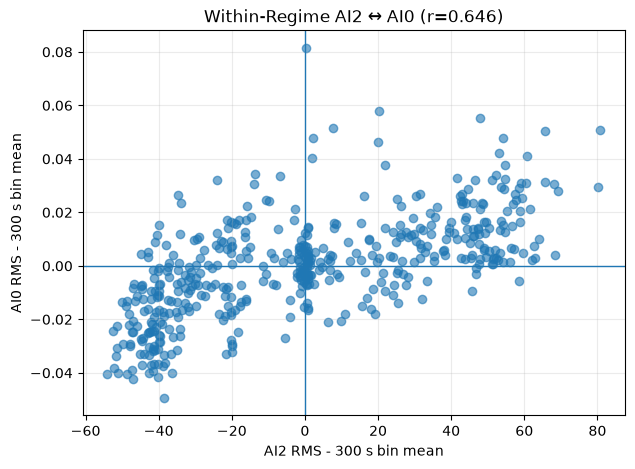

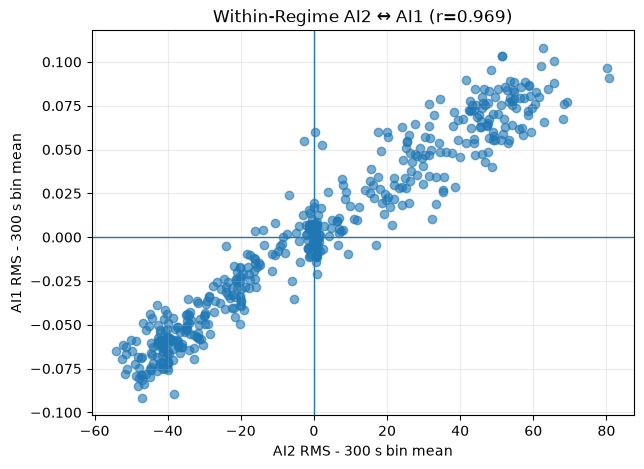

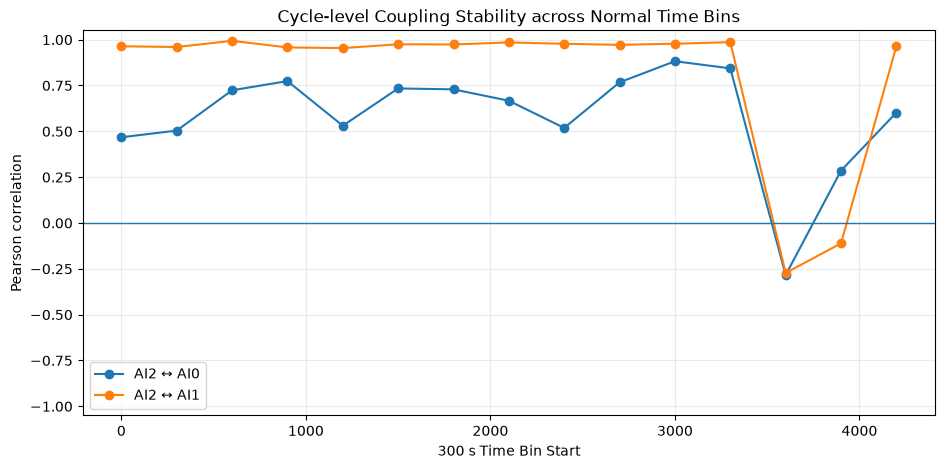

In [12]:
# Global AI2-Vibration 관계가 시간대별 regime 이동 때문인지 cycle-level coupling인지 분리한다.
# 300초 블록별 상관관계를 계산하고 각 블록 평균을 제거한 centered correlation도 구한다.
# AI2-AI0, AI2-AI1 관계가 Normal 내부에서도 반복적으로 유지되는지 확인한다.
# 이 검증 후 Global vibration EDA를 종료하고 abnormal 비교 단계로 넘어간다.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

TIME_BIN_SEC = 300
MIN_CYCLES_PER_BIN = 15

within = coupling.copy()

within["time_bin"] = (
    np.floor(within["start_elapsed_sec"] / TIME_BIN_SEC)
    * TIME_BIN_SEC
).astype(int)

def bin_stats(g):
    def safe_corr(a, b):
        return a.corr(b) if a.std() > 0 and b.std() > 0 else np.nan

    return pd.Series({
        "n": len(g),
        "AI2_mean": g["AI2_Current_rms"].mean(),
        "AI2_std": g["AI2_Current_rms"].std(),
        "AI0_mean": g["AI0_Vibration_rms"].mean(),
        "AI1_mean": g["AI1_Vibration_rms"].mean(),
        "corr_AI2_AI0": safe_corr(
            g["AI2_Current_rms"],
            g["AI0_Vibration_rms"]
        ),
        "corr_AI2_AI1": safe_corr(
            g["AI2_Current_rms"],
            g["AI1_Vibration_rms"]
        ),
        "corr_AI0_AI1": safe_corr(
            g["AI0_Vibration_rms"],
            g["AI1_Vibration_rms"]
        )
    })

bin_summary = (
    within.groupby("time_bin")
    .apply(bin_stats, include_groups=False)
)

bin_summary = bin_summary[
    bin_summary["n"] >= MIN_CYCLES_PER_BIN
]

print("=== 300 s Within-Regime Correlations ===")
display(bin_summary.round(4))

# 블록 평균 제거
for col in [
    "AI2_Current_rms",
    "AI0_Vibration_rms",
    "AI1_Vibration_rms"
]:
    within[f"{col}_centered"] = (
        within[col]
        - within.groupby("time_bin")[col].transform("mean")
    )

corr_ai2_ai0_centered = within[
    "AI2_Current_rms_centered"
].corr(
    within["AI0_Vibration_rms_centered"]
)

corr_ai2_ai1_centered = within[
    "AI2_Current_rms_centered"
].corr(
    within["AI1_Vibration_rms_centered"]
)

corr_ai0_ai1_centered = within[
    "AI0_Vibration_rms_centered"
].corr(
    within["AI1_Vibration_rms_centered"]
)

print("\n=== Global vs Within-Bin Centered Correlation ===")
print(
    f"AI2 ↔ AI0 | Global={within['AI2_Current_rms'].corr(within['AI0_Vibration_rms']):.4f} "
    f"| Centered={corr_ai2_ai0_centered:.4f}"
)
print(
    f"AI2 ↔ AI1 | Global={within['AI2_Current_rms'].corr(within['AI1_Vibration_rms']):.4f} "
    f"| Centered={corr_ai2_ai1_centered:.4f}"
)
print(
    f"AI0 ↔ AI1 | Global={within['AI0_Vibration_rms'].corr(within['AI1_Vibration_rms']):.4f} "
    f"| Centered={corr_ai0_ai1_centered:.4f}"
)

# AI2 ↔ AI0 centered scatter
plt.figure(figsize=(7, 5))
plt.scatter(
    within["AI2_Current_rms_centered"],
    within["AI0_Vibration_rms_centered"],
    alpha=0.6
)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("AI2 RMS - 300 s bin mean")
plt.ylabel("AI0 RMS - 300 s bin mean")
plt.title(
    f"Within-Regime AI2 ↔ AI0 "
    f"(r={corr_ai2_ai0_centered:.3f})"
)
plt.grid(alpha=0.25)
plt.show()

# AI2 ↔ AI1 centered scatter
plt.figure(figsize=(7, 5))
plt.scatter(
    within["AI2_Current_rms_centered"],
    within["AI1_Vibration_rms_centered"],
    alpha=0.6
)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("AI2 RMS - 300 s bin mean")
plt.ylabel("AI1 RMS - 300 s bin mean")
plt.title(
    f"Within-Regime AI2 ↔ AI1 "
    f"(r={corr_ai2_ai1_centered:.3f})"
)
plt.grid(alpha=0.25)
plt.show()

# 시간대별 상관계수
plt.figure(figsize=(11, 5))
plt.plot(
    bin_summary.index,
    bin_summary["corr_AI2_AI0"],
    marker="o",
    label="AI2 ↔ AI0"
)
plt.plot(
    bin_summary.index,
    bin_summary["corr_AI2_AI1"],
    marker="o",
    label="AI2 ↔ AI1"
)
plt.axhline(0, linewidth=1)
plt.ylim(-1.05, 1.05)
plt.xlabel("300 s Time Bin Start")
plt.ylabel("Pearson correlation")
plt.title("Cycle-level Coupling Stability across Normal Time Bins")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

=== Abnormal Full-Cycle Extraction ===
Rows: 600 | Segments: 21 | Full cycles: 8


c:\Users\astra\Desktop\K_eng\.venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
c:\Users\astra\Desktop\K_eng\.venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


,segment_id,cycle_id,duration_sec,AI2_Current_rms,AI0_Vibration_rms,AI1_Vibration_rms,AI0_residual,AI1_residual,vib_log_ratio
0,A0001,1,1.3,97.813913,0.539053,0.287104,0.481787,0.217222,0.629969
1,A0001,2,1.3,110.189182,0.483631,0.304030,0.421298,0.215747,0.464196
2,A0006,1,1.5,178.895893,0.770306,0.301004,0.679839,0.110556,0.939664
3,A0011,1,1.6,52.919360,0.082136,0.160300,0.043253,0.157175,-0.668669
4,A0011,2,1.6,73.612278,0.462612,0.271137,0.415256,0.237242,0.534266
5,A0012,1,1.9,64.264209,0.425155,0.202889,0.381626,0.182895,0.739795
6,A0016,1,1.2,206.576079,0.033679,0.059966,-0.068122,-0.171641,-0.576915
7,A0017,1,1.6,302.615996,0.445051,0.254345,0.303925,-0.120070,0.559496


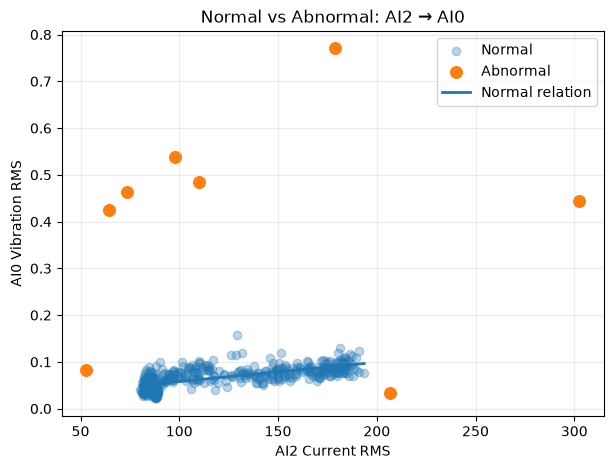

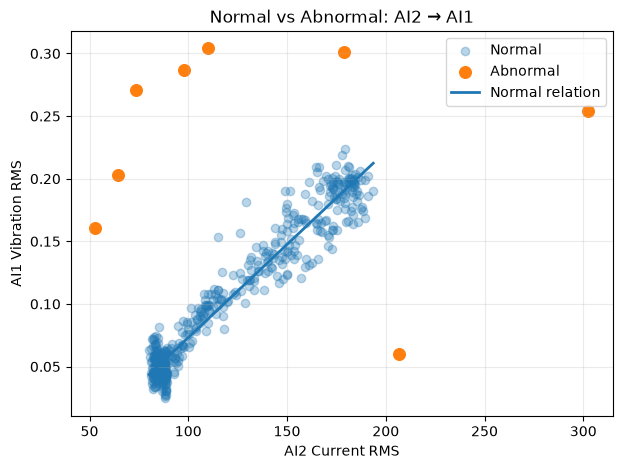

In [14]:
# Abnormal full-cycle을 Normal 기준으로 추출하고 RMS/residual을 계산한다.
# Normal의 AI2→AI0/AI1 관계는 고정해서 사용한다.
# 짧은 segment는 이후 Local Form 분석 대상으로 남긴다.

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import find_peaks
from sklearn.linear_model import LinearRegression

abnormal = data[data["source"] == "abnormal"].copy()
records = []

for seg_id, g in abnormal.groupby("segment_id", sort=False):
    if len(g) < MIN_SEGMENT_ROWS: continue
    y = g["AI2_Current"].to_numpy(float)
    smooth = pd.Series(y).rolling(3, center=True, min_periods=1).median().to_numpy()
    prom = max(np.std(smooth, ddof=1) * 0.5, np.finfo(float).eps)
    peaks, _ = find_peaks(smooth, distance=MIN_PEAK_DISTANCE, prominence=prom)

    for cycle_id, (s, e) in enumerate(zip(peaks[:-1], peaks[1:]), 1):
        if e - s < MIN_PEAK_DISTANCE: continue
        c = g.iloc[s:e+1]
        duration = c["elapsed_sec"].iloc[-1] - c["elapsed_sec"].iloc[0]
        if duration <= 0: continue

        r = {"segment_id": seg_id, "cycle_id": cycle_id,
             "duration_sec": duration, "n_samples": len(c)}

        for ch in ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]:
            x = c[ch].to_numpy(float)
            r[f"{ch}_rms"] = np.sqrt(np.mean(x**2))

        records.append(r)

abnormal_cycles = pd.DataFrame(records)

print("=== Abnormal Full-Cycle Extraction ===")
print(f"Rows: {len(abnormal):,} | Segments: {abnormal['segment_id'].nunique()} | Full cycles: {len(abnormal_cycles)}")

if len(abnormal_cycles):
    Xn = global_features[["AI2_Current_rms"]].to_numpy()
    models = {}

    for ch in ["AI0", "AI1"]:
        y = global_features[f"{ch}_Vibration_rms"].to_numpy()
        model = LinearRegression().fit(Xn, y)
        models[ch] = model
        abnormal_cycles[f"{ch}_expected_rms"] = model.predict(abnormal_cycles[["AI2_Current_rms"]])
        abnormal_cycles[f"{ch}_residual"] = (
            abnormal_cycles[f"{ch}_Vibration_rms"] -
            abnormal_cycles[f"{ch}_expected_rms"]
        )

    abnormal_cycles["vib_log_ratio"] = np.log(
        abnormal_cycles["AI0_Vibration_rms"] /
        abnormal_cycles["AI1_Vibration_rms"]
    )

    cols = ["segment_id", "cycle_id", "duration_sec", "AI2_Current_rms",
            "AI0_Vibration_rms", "AI1_Vibration_rms",
            "AI0_residual", "AI1_residual", "vib_log_ratio"]
    display(abnormal_cycles[cols].round(6))

    x_line = np.linspace(
        global_features["AI2_Current_rms"].min(),
        global_features["AI2_Current_rms"].max(), 200
    ).reshape(-1, 1)

    for ch in ["AI0", "AI1"]:
        plt.figure(figsize=(7, 5))
        plt.scatter(global_features["AI2_Current_rms"],
                    global_features[f"{ch}_Vibration_rms"],
                    alpha=0.3, label="Normal")
        plt.scatter(abnormal_cycles["AI2_Current_rms"],
                    abnormal_cycles[f"{ch}_Vibration_rms"],
                    s=70, label="Abnormal")
        plt.plot(x_line[:, 0], models[ch].predict(x_line),
                 linewidth=2, label="Normal relation")
        plt.xlabel("AI2 Current RMS")
        plt.ylabel(f"{ch} Vibration RMS")
        plt.title(f"Normal vs Abnormal: AI2 → {ch}")
        plt.legend()
        plt.grid(alpha=0.25)
        plt.show()
else:
    print("완전한 Abnormal Cycle 없음 → Local Form 분석으로 이동")

In [15]:
# Abnormal full-cycle을 Timing, AI2 range, AI0/AI1 coupling 축으로 정량화한다.
# Normal residual 분포로 z-score를 만들고 regression extrapolation 여부를 구분한다.
# Normal 범위 밖 AI2는 residual보다 operating-intensity anomaly로 우선 해석한다.
# 각 Cycle이 어떤 이상축에서 깨지는지 한 표로 정리한다.

import numpy as np
import pandas as pd

ab = abnormal_cycles.copy()

# Normal reference
dur_q1, dur_q3 = global_features["duration_sec"].quantile([.25, .75])
ai2_min = global_features["AI2_Current_rms"].min()
ai2_max = global_features["AI2_Current_rms"].max()

r0_mu = gf["AI0_residual"].mean()
r0_sd = gf["AI0_residual"].std(ddof=1)
r1_mu = gf["AI1_residual"].mean()
r1_sd = gf["AI1_residual"].std(ddof=1)

ratio_q1, ratio_q3 = coupling["vib_log_ratio"].quantile([.25, .75])
ratio_iqr = ratio_q3 - ratio_q1
ratio_lo = ratio_q1 - 1.5 * ratio_iqr
ratio_hi = ratio_q3 + 1.5 * ratio_iqr

# 이상축
ab["duration_normal"] = ab["duration_sec"].between(dur_q1, dur_q3)
ab["ai2_in_normal_range"] = ab["AI2_Current_rms"].between(ai2_min, ai2_max)

ab["AI0_resid_z"] = (ab["AI0_residual"] - r0_mu) / r0_sd
ab["AI1_resid_z"] = (ab["AI1_residual"] - r1_mu) / r1_sd

ab["AI0_coupling_break"] = ab["AI0_resid_z"].abs() > 3
ab["AI1_coupling_break"] = ab["AI1_resid_z"].abs() > 3
ab["balance_break"] = ~ab["vib_log_ratio"].between(ratio_lo, ratio_hi)

ab["broken_axes"] = (
    (~ab["duration_normal"]).astype(int)
    + (~ab["ai2_in_normal_range"]).astype(int)
    + ab["AI0_coupling_break"].astype(int)
    + ab["AI1_coupling_break"].astype(int)
    + ab["balance_break"].astype(int)
)

cols = [
    "segment_id", "cycle_id", "duration_sec",
    "AI2_Current_rms", "duration_normal", "ai2_in_normal_range",
    "AI0_resid_z", "AI1_resid_z",
    "AI0_coupling_break", "AI1_coupling_break",
    "balance_break", "broken_axes"
]

print("=== Normal Reference ===")
print(f"Duration IQR : {dur_q1:.2f} ~ {dur_q3:.2f} s")
print(f"AI2 RMS range: {ai2_min:.2f} ~ {ai2_max:.2f}")
print(f"AI0 residual SD: {r0_sd:.5f}")
print(f"AI1 residual SD: {r1_sd:.5f}")

print("\n=== Abnormal Full-Cycle Failure Axes ===")
display(ab[cols].round(3))

print("\n=== Failure Count ===")
print(f"Timing break      : {(~ab['duration_normal']).sum()} / {len(ab)}")
print(f"AI2 range break   : {(~ab['ai2_in_normal_range']).sum()} / {len(ab)}")
print(f"AI0 coupling break: {ab['AI0_coupling_break'].sum()} / {len(ab)}")
print(f"AI1 coupling break: {ab['AI1_coupling_break'].sum()} / {len(ab)}")
print(f"Balance break     : {ab['balance_break'].sum()} / {len(ab)}")

=== Normal Reference ===
Duration IQR : 1.60 ~ 1.70 s
AI2 RMS range: 80.22 ~ 193.63
AI0 residual SD: 0.01579
AI1 residual SD: 0.01485

=== Abnormal Full-Cycle Failure Axes ===


,segment_id,cycle_id,duration_sec,AI2_Current_rms,duration_normal,ai2_in_normal_range,AI0_resid_z,AI1_resid_z,AI0_coupling_break,AI1_coupling_break,balance_break,broken_axes
0,A0001,1,1.3,97.814,False,True,30.515,14.629,True,True,False,3
1,A0001,2,1.3,110.189,False,True,26.684,14.530,True,True,False,3
2,A0006,1,1.5,178.896,False,True,43.060,7.446,True,True,True,4
3,A0011,1,1.6,52.919,False,False,2.740,10.585,False,True,False,3
4,A0011,2,1.6,73.612,False,False,26.301,15.977,True,True,False,4
5,A0012,1,1.9,64.264,False,False,24.171,12.317,True,True,False,4
6,A0016,1,1.2,206.576,False,False,-4.315,-11.559,True,True,False,4
7,A0017,1,1.6,302.616,False,False,19.250,-8.086,True,True,False,4



=== Failure Count ===
Timing break      : 8 / 8
AI2 range break   : 5 / 8
AI0 coupling break: 7 / 8
AI1 coupling break: 8 / 8
Balance break     : 1 / 8


In [16]:
# Timing float 오차를 수정하고 Abnormal full-cycle 이상축을 다시 분류한다.
# AI2가 Normal 범위 안일 때만 Current-Vibration coupling break를 판정한다.
# AI2 범위 밖은 coupling anomaly가 아니라 Operating-state OOD로 우선 분류한다.
# 각 Cycle의 Timing / OOD / Coupling / Balance 이상을 최종 정리한다.

ab = abnormal_cycles.copy()
ab["duration_01s"] = ab["duration_sec"].round(1)

ai2_min = global_features["AI2_Current_rms"].min()
ai2_max = global_features["AI2_Current_rms"].max()

r0_mu, r0_sd = gf["AI0_residual"].mean(), gf["AI0_residual"].std(ddof=1)
r1_mu, r1_sd = gf["AI1_residual"].mean(), gf["AI1_residual"].std(ddof=1)

q1, q3 = coupling["vib_log_ratio"].quantile([.25, .75])
iqr = q3 - q1
ratio_lo, ratio_hi = q1 - 1.5*iqr, q3 + 1.5*iqr

ab["timing_break"] = ~ab["duration_01s"].between(1.6, 1.7)
ab["ai2_ood"] = ~ab["AI2_Current_rms"].between(ai2_min, ai2_max)

ab["AI0_resid_z"] = (ab["AI0_residual"] - r0_mu) / r0_sd
ab["AI1_resid_z"] = (ab["AI1_residual"] - r1_mu) / r1_sd

ab["AI0_coupling_break"] = (~ab["ai2_ood"]) & (ab["AI0_resid_z"].abs() > 3)
ab["AI1_coupling_break"] = (~ab["ai2_ood"]) & (ab["AI1_resid_z"].abs() > 3)

ab["balance_break"] = ~ab["vib_log_ratio"].between(ratio_lo, ratio_hi)

ab["broken_axes"] = (
    ab["timing_break"].astype(int)
    + ab["ai2_ood"].astype(int)
    + ab["AI0_coupling_break"].astype(int)
    + ab["AI1_coupling_break"].astype(int)
    + ab["balance_break"].astype(int)
)

cols = [
    "segment_id", "cycle_id", "duration_01s", "AI2_Current_rms",
    "timing_break", "ai2_ood", "AI0_resid_z", "AI1_resid_z",
    "AI0_coupling_break", "AI1_coupling_break",
    "balance_break", "broken_axes"
]

display(ab[cols].round(3))

valid = ab[~ab["ai2_ood"]]

print("=== Corrected Failure Count ===")
print(f"Timing break       : {ab['timing_break'].sum()} / {len(ab)}")
print(f"AI2 OOD            : {ab['ai2_ood'].sum()} / {len(ab)}")
print(f"Coupling evaluable : {len(valid)} / {len(ab)}")
print(f"AI0 coupling break : {valid['AI0_coupling_break'].sum()} / {len(valid)}")
print(f"AI1 coupling break : {valid['AI1_coupling_break'].sum()} / {len(valid)}")
print(f"Balance break      : {ab['balance_break'].sum()} / {len(ab)}")

,segment_id,cycle_id,duration_01s,AI2_Current_rms,timing_break,ai2_ood,AI0_resid_z,AI1_resid_z,AI0_coupling_break,AI1_coupling_break,balance_break,broken_axes
0,A0001,1,1.3,97.814,True,False,30.515,14.629,True,True,False,3
1,A0001,2,1.3,110.189,True,False,26.684,14.530,True,True,False,3
2,A0006,1,1.5,178.896,True,False,43.060,7.446,True,True,True,4
3,A0011,1,1.6,52.919,False,True,2.740,10.585,False,False,False,1
4,A0011,2,1.6,73.612,False,True,26.301,15.977,False,False,False,1
5,A0012,1,1.9,64.264,True,True,24.171,12.317,False,False,False,2
6,A0016,1,1.2,206.576,True,True,-4.315,-11.559,False,False,False,2
7,A0017,1,1.6,302.616,False,True,19.250,-8.086,False,False,False,1


=== Corrected Failure Count ===
Timing break       : 5 / 8
AI2 OOD            : 5 / 8
Coupling evaluable : 3 / 8
AI0 coupling break : 3 / 3
AI1 coupling break : 3 / 3
Balance break      : 1 / 8


=== Normal Local Phase Dictionary ===
Local length : 5 samples
Templates    : 13


,start_pct,end_pct,rmse_med,rmse_q95,corr_med,corr_q05
local_phase,,,,,,
0,0.00,25.00,0.0746,0.1375,0.9963,0.9834
1,6.25,31.25,0.0724,0.1649,0.9987,0.9940
2,12.50,37.50,0.0782,0.1918,0.9991,0.9965
3,18.75,43.75,0.0899,0.2038,0.9993,0.9962
4,25.00,50.00,0.0881,0.1936,0.9988,0.9956
5,31.25,56.25,0.0818,0.1704,0.9967,0.9899
6,37.50,62.50,0.0707,0.1388,0.9929,0.9743
7,43.75,68.75,0.0617,0.1112,0.9667,0.8574
8,50.00,75.00,0.0632,0.1186,0.9949,0.9747


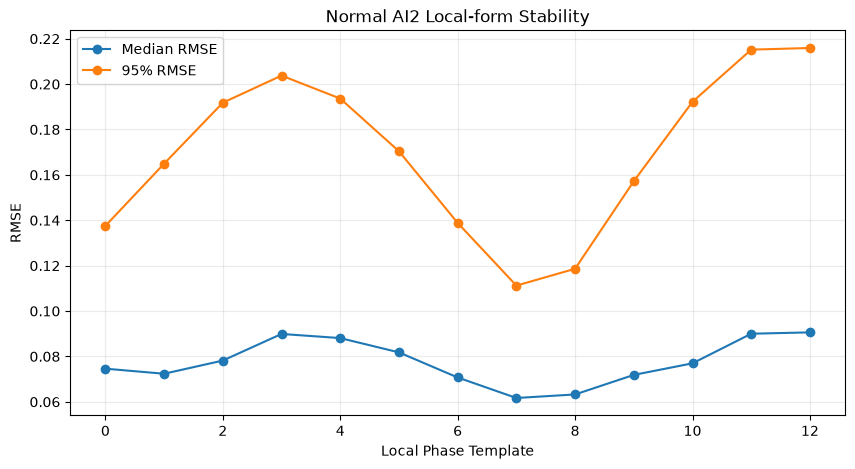

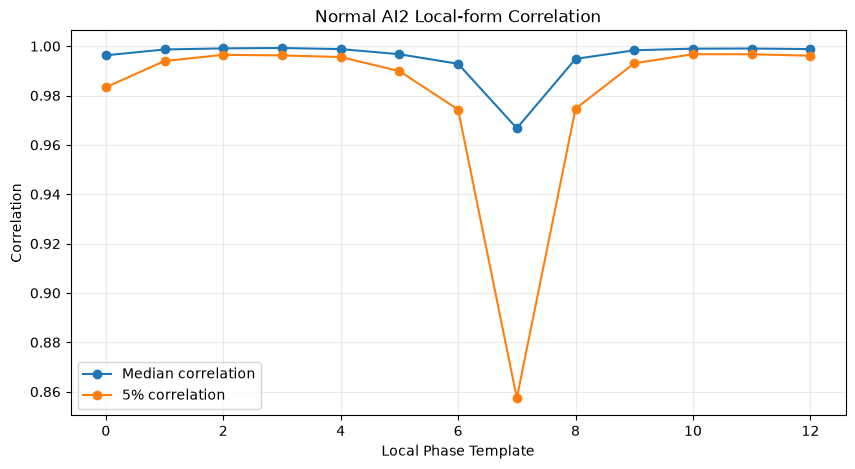

In [17]:
# Normal AI2 Cycle로 5-sample Local Phase Template 13개를 만든다.
# 각 local window는 whole-cycle z-normalization 상태에서 비교한다.
# Phase별 median template과 Normal 내부 RMSE 분포를 계산한다.
# 이 Normal 기준을 고정한 뒤 다음 단계에서 짧은 Abnormal fragment에 적용한다.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LOCAL_LEN = 5
n_local = N_PHASE_POINTS - LOCAL_LEN + 1
local_rows, local_templates = [], []

for start in range(n_local):
    windows = ai2_cycles_norm[:, start:start + LOCAL_LEN]
    template = np.median(windows, axis=0)
    local_templates.append(template)

    for i, w in enumerate(windows):
        rmse = np.sqrt(np.mean((w - template) ** 2))
        corr = np.corrcoef(w, template)[0, 1]
        local_rows.append({
            "cycle_idx": i, "local_phase": start,
            "start_pct": phase_grid[start] * 100,
            "end_pct": phase_grid[start + LOCAL_LEN - 1] * 100,
            "rmse": rmse, "corr": corr
        })

local_templates = np.asarray(local_templates)
local_ref = pd.DataFrame(local_rows)

local_summary = local_ref.groupby("local_phase").agg(
    start_pct=("start_pct", "first"),
    end_pct=("end_pct", "first"),
    rmse_med=("rmse", "median"),
    rmse_q95=("rmse", lambda x: x.quantile(.95)),
    corr_med=("corr", "median"),
    corr_q05=("corr", lambda x: x.quantile(.05))
)

print("=== Normal Local Phase Dictionary ===")
print(f"Local length : {LOCAL_LEN} samples")
print(f"Templates    : {n_local}")
display(local_summary.round(4))

plt.figure(figsize=(10, 5))
plt.plot(local_summary.index, local_summary["rmse_med"],
         marker="o", label="Median RMSE")
plt.plot(local_summary.index, local_summary["rmse_q95"],
         marker="o", label="95% RMSE")
plt.xlabel("Local Phase Template")
plt.ylabel("RMSE")
plt.title("Normal AI2 Local-form Stability")
plt.legend()
plt.grid(alpha=.25)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(local_summary.index, local_summary["corr_med"],
         marker="o", label="Median correlation")
plt.plot(local_summary.index, local_summary["corr_q05"],
         marker="o", label="5% correlation")
plt.xlabel("Local Phase Template")
plt.ylabel("Correlation")
plt.title("Normal AI2 Local-form Correlation")
plt.legend()
plt.grid(alpha=.25)
plt.show()

=== Normal Local Matching Reference ===
RMSE 95% threshold : 0.2132
Corr 5% threshold  : 0.9716

=== Partial Abnormal Local-form Summary ===


,n_windows,best_rmse_med,best_rmse_max,bad_rmse_frac,corr_med,bad_corr_frac
segment_id,,,,,,
A0002,43,0.7984,1.2463,1.0000,0.6016,1.0000
A0007,36,0.8037,1.1806,1.0000,0.5963,1.0000
A0013,24,0.8113,1.2055,1.0000,0.5886,1.0000
A0009,4,0.7413,1.0377,1.0000,0.6551,1.0000
A0020,11,0.9756,1.1954,1.0000,0.4051,1.0000
A0019,6,0.9663,1.1955,1.0000,0.3980,1.0000
A0014,11,0.9957,1.1562,1.0000,0.3804,1.0000
A0018,20,0.6448,1.1809,1.0000,0.7398,1.0000
A0015,46,0.8062,1.2008,0.9783,0.5937,0.9783


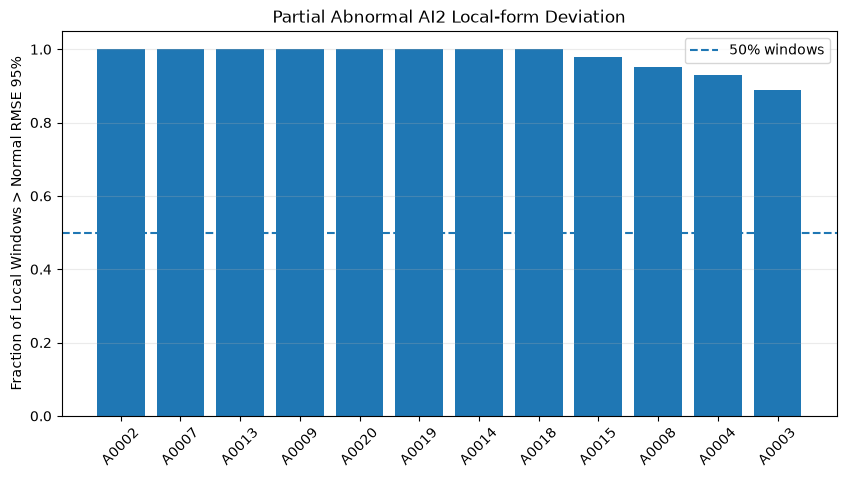

In [18]:
# Normal 5-sample AI2 Local Shape Dictionary를 만들고 Partial Abnormal에 적용한다.
# 각 5-sample window는 local z-normalization 후 Normal 13개 phase template과 비교한다.
# Normal best-match RMSE 95%를 기준으로 Abnormal local-shape deviation을 표시한다.
# Full-cycle이 이미 잡힌 Abnormal segment는 제외하고 partial segment만 분석한다.

import numpy as np, pandas as pd, matplotlib.pyplot as plt

L = 5
z = lambda x: (x - np.mean(x)) / (np.std(x, ddof=1) + 1e-12)

# Normal local shape template
normal_local = []
for p in range(N_PHASE_POINTS - L + 1):
    w = np.array([z(x[p:p+L]) for x in ai2_cycles_raw])
    t = z(np.median(w, axis=0))
    normal_local.append(t)
normal_local = np.array(normal_local)

# Normal best-match 분포로 threshold 설정
normal_scores = []
for x in ai2_cycles_raw:
    for s in range(N_PHASE_POINTS - L + 1):
        w = z(x[s:s+L])
        rmses = np.sqrt(np.mean((normal_local - w) ** 2, axis=1))
        best = np.argmin(rmses)
        normal_scores.append({
            "rmse": rmses[best],
            "corr": np.corrcoef(w, normal_local[best])[0, 1]
        })

normal_scores = pd.DataFrame(normal_scores)
RMSE_THR = normal_scores["rmse"].quantile(.95)
CORR_THR = normal_scores["corr"].quantile(.05)

print("=== Normal Local Matching Reference ===")
print(f"RMSE 95% threshold : {RMSE_THR:.4f}")
print(f"Corr 5% threshold  : {CORR_THR:.4f}")

# Full-cycle 없는 Abnormal segment만 사용
full_segments = set(abnormal_cycles["segment_id"])
partial = abnormal[~abnormal["segment_id"].isin(full_segments)].copy()

rows = []
for seg_id, g in partial.groupby("segment_id", sort=False):
    x = g["AI2_Current"].to_numpy(float)
    if len(x) < L: continue

    for s in range(len(x) - L + 1):
        w = z(x[s:s+L])
        rmses = np.sqrt(np.mean((normal_local - w) ** 2, axis=1))
        best = np.argmin(rmses)
        corr = np.corrcoef(w, normal_local[best])[0, 1]

        rows.append({
            "segment_id": seg_id, "window": s,
            "best_phase": best, "rmse": rmses[best], "corr": corr,
            "rmse_break": rmses[best] > RMSE_THR,
            "corr_break": corr < CORR_THR
        })

local_ab = pd.DataFrame(rows)

summary = local_ab.groupby("segment_id").agg(
    n_windows=("window", "count"),
    best_rmse_med=("rmse", "median"),
    best_rmse_max=("rmse", "max"),
    bad_rmse_frac=("rmse_break", "mean"),
    corr_med=("corr", "median"),
    bad_corr_frac=("corr_break", "mean")
).sort_values("bad_rmse_frac", ascending=False)

print("\n=== Partial Abnormal Local-form Summary ===")
display(summary.round(4))

plt.figure(figsize=(10, 5))
plt.bar(summary.index, summary["bad_rmse_frac"])
plt.axhline(.5, linestyle="--", label="50% windows")
plt.xticks(rotation=45)
plt.ylabel("Fraction of Local Windows > Normal RMSE 95%")
plt.title("Partial Abnormal AI2 Local-form Deviation")
plt.legend()
plt.grid(axis="y", alpha=.25)
plt.show()

In [19]:
# Normal segment를 Train/Holdout으로 분리해 Local Form 기준의 과적합을 검사한다.
# Train Normal만으로 5-sample template을 만들고 Holdout Normal로 95% RMSE를 정한다.
# 그 threshold를 Partial Abnormal에 그대로 적용한다.
# Correlation은 RMSE와 중복되므로 Local Form에서는 제외한다.

import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

keys = pd.DataFrame(cycle_keys, columns=["segment_id", "cycle_id"])
segments = keys["segment_id"].unique()
train_seg, val_seg = train_test_split(segments, test_size=.3, random_state=42)

train_idx = keys["segment_id"].isin(train_seg).to_numpy()
val_idx = keys["segment_id"].isin(val_seg).to_numpy()

L = 5
z = lambda x: (x-x.mean())/(x.std(ddof=1)+1e-12)

templates = []
for p in range(N_PHASE_POINTS-L+1):
    w = np.array([z(x[p:p+L]) for x in ai2_cycles_raw[train_idx]])
    templates.append(z(np.median(w, axis=0)))
templates = np.array(templates)

def best_rmse(w):
    w = z(np.asarray(w, float))
    return np.sqrt(np.mean((templates-w)**2, axis=1)).min()

val_scores = []
for x in ai2_cycles_raw[val_idx]:
    for s in range(N_PHASE_POINTS-L+1):
        val_scores.append(best_rmse(x[s:s+L]))

RMSE_THR_HOLDOUT = np.quantile(val_scores, .95)

full_segments = set(abnormal_cycles["segment_id"])
partial = abnormal[~abnormal["segment_id"].isin(full_segments)].copy()
rows = []

for seg_id, g in partial.groupby("segment_id", sort=False):
    x = g["AI2_Current"].to_numpy(float)
    if len(x) < L: continue
    scores = [best_rmse(x[s:s+L]) for s in range(len(x)-L+1)]
    rows.append({
        "segment_id": seg_id, "n_windows": len(scores),
        "rmse_med": np.median(scores), "rmse_max": np.max(scores),
        "bad_frac": np.mean(np.array(scores) > RMSE_THR_HOLDOUT)
    })

holdout_result = pd.DataFrame(rows).set_index("segment_id")

print("=== Holdout Local Form Validation ===")
print(f"Train segments     : {len(train_seg)}")
print(f"Validation segments: {len(val_seg)}")
print(f"Holdout RMSE 95%   : {RMSE_THR_HOLDOUT:.4f}")
print(f"Partial evaluable  : {len(holdout_result)}")
display(holdout_result.sort_values("bad_frac", ascending=False).round(4))

all_partial = set(partial["segment_id"].unique())
evaluated = set(holdout_result.index)
print("Too short (<5 samples):", sorted(all_partial-evaluated))

=== Holdout Local Form Validation ===
Train segments     : 236
Validation segments: 102
Holdout RMSE 95%   : 0.2233
Partial evaluable  : 12


,n_windows,rmse_med,rmse_max,bad_frac
segment_id,,,,
A0002,43,0.7997,1.2452,1.0000
A0007,36,0.8041,1.1810,1.0000
A0013,24,0.8123,1.2041,1.0000
A0009,4,0.7391,1.0374,1.0000
A0020,11,0.9755,1.1939,1.0000
A0019,6,0.9658,1.1956,1.0000
A0014,11,0.9967,1.1574,1.0000
A0018,20,0.6453,1.1809,1.0000
A0015,46,0.8060,1.2010,0.9783


Too short (<5 samples): ['A0000', 'A0005', 'A0010']


=== Normal Holdout Cyclic Reference ===
RMSE 95% threshold    : 0.2771
Progression 5% cutoff : 1.0000
Median progression    : 1.0000

=== Partial Abnormal Local Phase Progression ===


,n_windows,rmse_med,bad_shape_frac,progression_ok,progression_break
segment_id,,,,,
A0007,36,0.6591,1.0000,0.3714,True
A0019,6,0.8772,1.0000,0.2000,True
A0014,11,0.9631,1.0000,0.2000,True
A0009,4,0.7391,1.0000,0.3333,True
A0020,11,0.8069,1.0000,0.2000,True
A0002,43,0.7548,0.9767,0.1905,True
A0015,46,0.7374,0.9130,0.2889,True
A0018,20,0.5174,0.9000,0.4211,True
A0003,27,0.7712,0.8889,0.3846,True


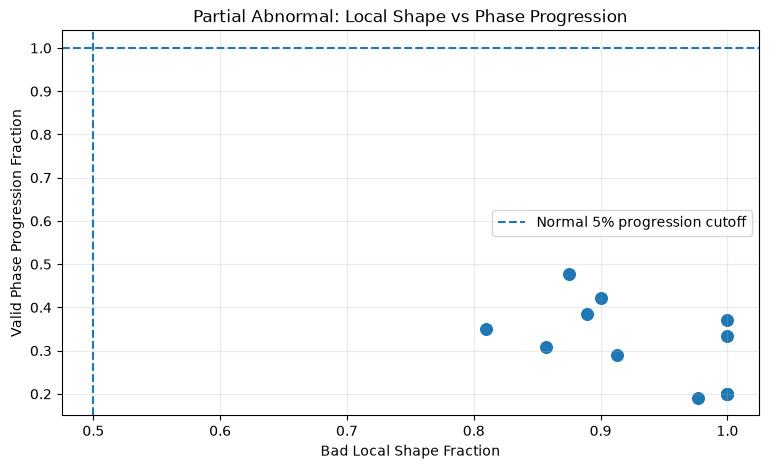

In [20]:
# Train Normal로 17개 cyclic Local Phase Template을 만든다.
# Holdout Normal에서 정상적인 phase progression 기준을 구한다.
# Partial Abnormal의 best phase가 +1 방향으로 진행하는지 비교한다.
# Local RMSE는 주 지표, phase progression은 보조 지표로 사용한다.

import numpy as np, pandas as pd, matplotlib.pyplot as plt

L, P = 5, N_PHASE_POINTS
z = lambda x: (x-x.mean())/(x.std(ddof=1)+1e-12)

def cycwin(x, p):
    return x[(np.arange(L)+p) % P]

# Train Normal cyclic templates
cyc_templates = []
for p in range(P):
    w = np.array([z(cycwin(x, p)) for x in ai2_cycles_raw[train_idx]])
    cyc_templates.append(z(np.median(w, axis=0)))
cyc_templates = np.array(cyc_templates)

def match_local(w):
    w = z(np.asarray(w, float))
    rmse = np.sqrt(np.mean((cyc_templates-w)**2, axis=1))
    p = int(np.argmin(rmse))
    return p, rmse[p]

def step_error(a, b):
    d = (b-a) % P
    return min((d-1) % P, (1-d) % P)

# Holdout Normal progression 기준
normal_prog, normal_rmse = [], []
for x in ai2_cycles_raw[val_idx]:
    pred, scores = [], []
    for p in range(P):
        bp, r = match_local(cycwin(x, p))
        pred.append(bp); scores.append(r)

    err = [step_error(a, b) for a, b in zip(pred[:-1], pred[1:])]
    normal_prog.append(np.mean(np.array(err) <= 1))
    normal_rmse.extend(scores)

PROG_THR = np.quantile(normal_prog, .05)
CYCLIC_RMSE_THR = np.quantile(normal_rmse, .95)

print("=== Normal Holdout Cyclic Reference ===")
print(f"RMSE 95% threshold    : {CYCLIC_RMSE_THR:.4f}")
print(f"Progression 5% cutoff : {PROG_THR:.4f}")
print(f"Median progression    : {np.median(normal_prog):.4f}")

# Partial Abnormal
rows = []
for seg_id, g in partial.groupby("segment_id", sort=False):
    x = g["AI2_Current"].to_numpy(float)
    if len(x) < L: continue

    phases, scores = [], []
    for s in range(len(x)-L+1):
        p, r = match_local(x[s:s+L])
        phases.append(p); scores.append(r)

    errors = [step_error(a, b) for a, b in zip(phases[:-1], phases[1:])]
    good = np.mean(np.array(errors) <= 1) if errors else np.nan

    rows.append({
        "segment_id": seg_id, "n_windows": len(scores),
        "rmse_med": np.median(scores),
        "bad_shape_frac": np.mean(np.array(scores) > CYCLIC_RMSE_THR),
        "progression_ok": good,
        "progression_break": good < PROG_THR if not np.isnan(good) else True
    })

progression_result = pd.DataFrame(rows).set_index("segment_id")

print("\n=== Partial Abnormal Local Phase Progression ===")
display(
    progression_result
    .sort_values("bad_shape_frac", ascending=False)
    .round(4)
)

plt.figure(figsize=(9, 5))
plt.scatter(
    progression_result["bad_shape_frac"],
    progression_result["progression_ok"],
    s=70
)
plt.axvline(.5, linestyle="--")
plt.axhline(PROG_THR, linestyle="--", label="Normal 5% progression cutoff")
plt.xlabel("Bad Local Shape Fraction")
plt.ylabel("Valid Phase Progression Fraction")
plt.title("Partial Abnormal: Local Shape vs Phase Progression")
plt.legend()
plt.grid(alpha=.25)
plt.show()

In [21]:
# Holdout Normal에서 Cycle별 bad Local Shape 비율의 정상 범위를 계산한다.
# Window RMSE threshold는 기존 CYCLIC_RMSE_THR을 그대로 사용한다.
# Normal Cycle별 bad fraction 95%를 Partial Abnormal 판정기준으로 고정한다.
# 이 기준으로 Local Shape / Progression 이상 여부를 최종 확정한다.

normal_cycle_ref = []

for x in ai2_cycles_raw[val_idx]:
    scores, phases = [], []

    for p in range(P):
        bp, r = match_local(cycwin(x, p))
        phases.append(bp)
        scores.append(r)

    err = [step_error(a, b) for a, b in zip(phases[:-1], phases[1:])]

    normal_cycle_ref.append({
        "bad_frac": np.mean(np.array(scores) > CYCLIC_RMSE_THR),
        "progression_ok": np.mean(np.array(err) <= 1)
    })

normal_cycle_ref = pd.DataFrame(normal_cycle_ref)

BAD_FRAC_THR = normal_cycle_ref["bad_frac"].quantile(.95)
PROG_THR_FINAL = normal_cycle_ref["progression_ok"].quantile(.05)

progression_result["shape_break"] = (
    progression_result["bad_shape_frac"] > BAD_FRAC_THR
)

progression_result["progression_break"] = (
    progression_result["progression_ok"] < PROG_THR_FINAL
)

print("=== Final Local Form Reference ===")
print(f"Normal bad-frac 95% : {BAD_FRAC_THR:.4f}")
print(f"Normal progression 5%: {PROG_THR_FINAL:.4f}")

print("\n=== Partial Abnormal Final Classification ===")
display(
    progression_result[
        ["n_windows", "rmse_med", "bad_shape_frac",
         "shape_break", "progression_ok", "progression_break"]
    ].round(4)
)

print("\n=== Detection Count ===")
print(
    f"Local shape break : "
    f"{progression_result['shape_break'].sum()} / "
    f"{len(progression_result)}"
)
print(
    f"Progression break : "
    f"{progression_result['progression_break'].sum()} / "
    f"{len(progression_result)}"
)

=== Final Local Form Reference ===
Normal bad-frac 95% : 0.1176
Normal progression 5%: 1.0000

=== Partial Abnormal Final Classification ===


,n_windows,rmse_med,bad_shape_frac,shape_break,progression_ok,progression_break
segment_id,,,,,,
A0002,43,0.7548,0.9767,True,0.1905,True
A0003,27,0.7712,0.8889,True,0.3846,True
A0004,14,0.7168,0.8571,True,0.3077,True
A0007,36,0.6591,1.0000,True,0.3714,True
A0008,21,0.5091,0.8095,True,0.3500,True
A0009,4,0.7391,1.0000,True,0.3333,True
A0013,24,0.6446,0.8750,True,0.4783,True
A0014,11,0.9631,1.0000,True,0.2000,True
A0015,46,0.7374,0.9130,True,0.2889,True



=== Detection Count ===
Local shape break : 12 / 12
Progression break : 12 / 12


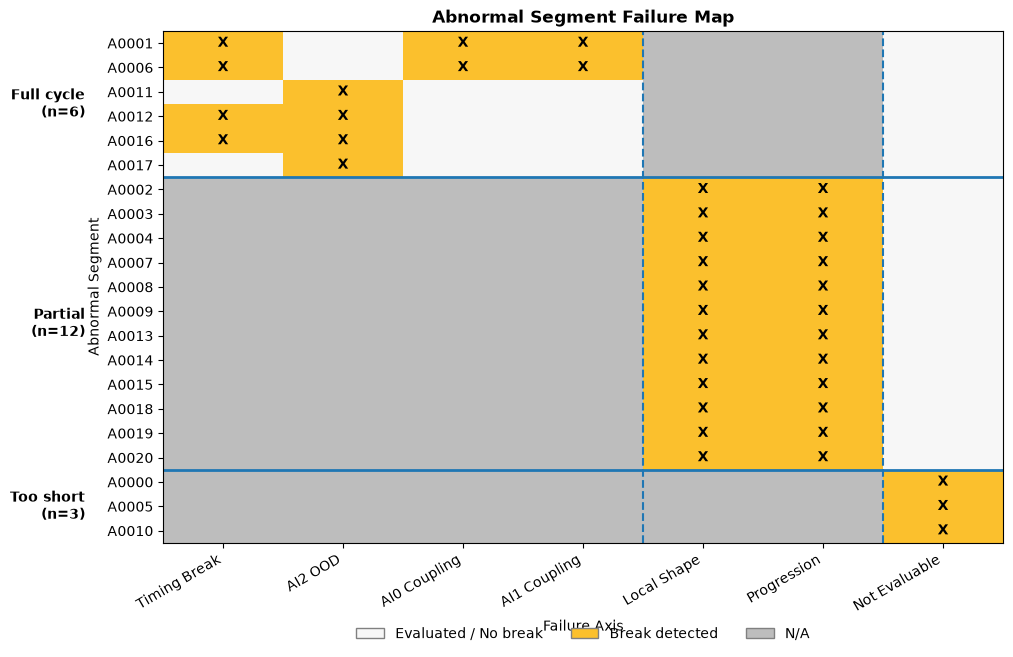

=== Coverage ===
Full cycle : 6
Partial    : 12
Too short  : 3
Evaluable  : 18 / 21


In [26]:
# Abnormal 21개 segment를 Full / Partial / Too-short Branch로 통합한다.
# Break / 정상 / N-A를 서로 다른 상태로 표시해 오해를 막는다.
# Global Cycle, Local Form, Coverage 축을 시각적으로 구분한다.
# 보고서용 최종 Failure Map으로 사용한다.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

segments = sorted(abnormal["segment_id"].unique())
fm = pd.DataFrame(index=segments)
fm.index.name = "segment_id"
fm["branch"] = "Too short"

cols = [
    "Timing Break", "AI2 OOD",
    "AI0 Coupling", "AI1 Coupling",
    "Local Shape", "Progression",
    "Not Evaluable"
]

for c in cols:
    fm[c] = False

# Full-cycle
for seg, g in ab.groupby("segment_id"):
    fm.loc[seg, "branch"] = "Full cycle"
    fm.loc[seg, "Timing Break"] = g["timing_break"].any()
    fm.loc[seg, "AI2 OOD"] = g["ai2_ood"].any()
    fm.loc[seg, "AI0 Coupling"] = g["AI0_coupling_break"].any()
    fm.loc[seg, "AI1 Coupling"] = g["AI1_coupling_break"].any()

# Partial
for seg, r in progression_result.iterrows():
    fm.loc[seg, "branch"] = "Partial"
    fm.loc[seg, "Local Shape"] = r["shape_break"]
    fm.loc[seg, "Progression"] = r["progression_break"]

# Too-short
fm.loc[fm["branch"] == "Too short", "Not Evaluable"] = True

order = {"Full cycle": 0, "Partial": 1, "Too short": 2}
fm_plot = (
    fm.reset_index()
    .assign(branch_order=lambda x: x["branch"].map(order))
    .sort_values(["branch_order", "segment_id"])
    .set_index("segment_id")
)

# 0 = evaluated/no break, 1 = break, 2 = N/A
state = fm_plot[cols].astype(int).to_numpy()

for i, branch in enumerate(fm_plot["branch"]):
    if branch == "Full cycle":
        state[i, 4:6] = 2
    elif branch == "Partial":
        state[i, 0:4] = 2
    else:
        state[i, 0:6] = 2

cmap = ListedColormap(["#F7F7F7", "#FBC02D", "#BDBDBD"])

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(state, aspect="auto", cmap=cmap, vmin=0, vmax=2)

ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=30, ha="right")
ax.set_yticks(range(len(fm_plot)))
ax.set_yticklabels(fm_plot.index)

# Break만 X 표시
for i in range(state.shape[0]):
    for j in range(state.shape[1]):
        if state[i, j] == 1:
            ax.text(j, i, "X", ha="center", va="center", fontweight="bold")

# Branch 경계
branches = fm_plot["branch"].to_numpy()
for i in range(1, len(branches)):
    if branches[i] != branches[i-1]:
        ax.axhline(i - .5, linewidth=2)

# 분석축 구분: Global | Local | Coverage
ax.axvline(3.5, linewidth=1.5, linestyle="--")
ax.axvline(5.5, linewidth=1.5, linestyle="--")

# Branch 이름 + 개수
for branch in ["Full cycle", "Partial", "Too short"]:
    idx = np.where(branches == branch)[0]
    if len(idx):
        mid = (idx[0] + idx[-1]) / 2
        ax.text(
            -1.15, mid,
            f"{branch}\n(n={len(idx)})",
            ha="right", va="center",
            fontweight="bold"
        )

legend = [
    Patch(facecolor="#F7F7F7", edgecolor="gray", label="Evaluated / No break"),
    Patch(facecolor="#FBC02D", edgecolor="gray", label="Break detected"),
    Patch(facecolor="#BDBDBD", edgecolor="gray", label="N/A")
]

ax.legend(
    handles=legend,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=3,
    frameon=False
)

ax.set_title("Abnormal Segment Failure Map", fontweight="bold")
ax.set_xlabel("Failure Axis")
ax.set_ylabel("Abnormal Segment")

plt.subplots_adjust(left=0.20, bottom=0.24)
plt.show()

print("=== Coverage ===")
print(f"Full cycle : {(fm['branch']=='Full cycle').sum()}")
print(f"Partial    : {(fm['branch']=='Partial').sum()}")
print(f"Too short  : {(fm['branch']=='Too short').sum()}")
print(f"Evaluable  : {(fm['branch']!='Too short').sum()} / {len(fm)}")